In [1]:
# import data & required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import ast
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

# Data collection:

In [2]:
# Create a function to get car details from the dataset
def get_car_details(df,location):
    current_year = datetime.now().year
    
    # Create a variable to assign the values
    car_name = []
    brand = []
    model = []
    vehicle_age = []
    km_driven = []
    no_of_owners = []
    fuel_type = []
    transmission_type = []
    mileage = []
    engine_cc = []
    max_power = []
    seats = []
    price = []
    
    for i in range(df.shape[0]):
        new_car_details = df['new_car_detail'][i]
        new_car_overview = df['new_car_overview'][i]
        new_car_specs = df['new_car_specs'][i]
        
        # Convert str dict into actual dictionary
        data_dict_details = ast.literal_eval(new_car_details)
        data_dict_overview = ast.literal_eval(new_car_overview)
        data_dict_specs = ast.literal_eval(new_car_specs)
        
        # Extract the car details and append it
        name = data_dict_details['model']
        car_name.append(name)
        
        name_parts = name.split()
        brand.append(name_parts[0])
        model.append(" ".join(name_parts[1:]))
        
        vehicle_age.append(current_year - data_dict_details['modelYear'])
        km_driven.append(data_dict_details['km'])
        no_of_owners.append(data_dict_details['ownerNo'])
        fuel_type.append(data_dict_details['ft'])
        transmission_type.append(data_dict_details['transmission'])          
        price.append(data_dict_details['price'])
        
        # Extract from new data specs['top']
        top_specs = {item['key'] : item['value'] for item in data_dict_specs.get('top',[])}
        mileage.append(top_specs.get('Mileage',np.nan))
        engine_cc.append(top_specs.get('Engine',np.nan))
        max_power.append(top_specs.get('Max Power',np.nan))
        seats.append(top_specs.get('Seats',np.nan))
        
    # Create a DataFrame with car details
    data_df = pd.DataFrame({
        "Car_Name" : car_name,
        "Brand" : brand,
        "Model" : model,
        "Vehicle_Age" : vehicle_age,
        "KM_Driven" : km_driven,
        "No_Of_Owners" : no_of_owners,
        "Fuel_Type" : fuel_type,
        "Transmission_Type" : transmission_type,
        "Mileage" : mileage,
        "Engine_CC" : engine_cc,
        "Max_Power" : max_power,
        "No_Of_Seats" : seats,
        "Price" : price
    })
    
    # Create a location feature
    data_df['Location'] = location
        
    # Return the DataFrame
    return data_df


## Bangalore Dataset:

In [3]:
# Load the bangalore dataset
bangalore_data = pd.read_excel(r"C:\Users\alexa\Desktop\GUVI\CAPSTONE PROJECTS\CAR_DEKHO\Datasets\bangalore_cars.xlsx")
bangalore_data.head()

,new_car_detail,new_car_overview,new_car_feature,new_car_specs,car_links
0,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
1,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
2,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
3,"{'it': 0, 'ft': 'Petrol', 'bt': 'Sedan', 'km':...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
4,"{'it': 0, 'ft': 'Diesel', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...


In [4]:
# Check the size of the dataset
bangalore_data.shape

(1481, 5)

In [5]:
# Get the car details
bangalore_df = get_car_details(bangalore_data,'bangalore')
bangalore_df

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Maruti Celerio,Maruti,Celerio,11,"1,20,000",3,Petrol,Manual,23.1 kmpl,998 CC,67.04bhp,5,₹ 4 Lakh,bangalore
1,Ford Ecosport,Ford,Ecosport,8,"32,706",2,Petrol,Manual,17 kmpl,1497 CC,121.31bhp,5,₹ 8.11 Lakh,bangalore
2,Tata Tiago,Tata,Tiago,8,"11,949",1,Petrol,Manual,23.84 kmpl,1199 CC,84bhp,5,₹ 5.85 Lakh,bangalore
3,Hyundai Xcent,Hyundai,Xcent,12,"17,794",1,Petrol,Manual,19.1 kmpl,1197 CC,81.86bhp,5,₹ 4.62 Lakh,bangalore
4,Maruti SX4 S Cross,Maruti,SX4 S Cross,11,"60,000",1,Diesel,Manual,23.65 kmpl,1248 CC,88.5bhp,5,₹ 7.90 Lakh,bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,Toyota Fortuner,Toyota,Fortuner,14,"1,56,039",2,Diesel,Manual,12.55 kmpl,2982 CC,168.5bhp,7,₹ 16.49 Lakh,bangalore
1477,Maruti SX4,Maruti,SX4,18,"56,000",2,Petrol,Manual,15 kmpl,1586 CC,104.68,5,₹ 3.30 Lakh,bangalore
1478,Honda Brio,Honda,Brio,12,"42,000",2,Petrol,Manual,19.4 kmpl,1198 CC,86.8bhp,5,₹ 4.25 Lakh,bangalore
1479,Hyundai i20,Hyundai,i20,8,"93,003",1,Diesel,Manual,22.54 kmpl,1396 CC,88.73bhp,5,₹ 7.50 Lakh,bangalore


In [6]:
# Check the data size after extracting car details
bangalore_df.shape

(1481, 14)

In [7]:
# Check the null values
bangalore_df.isnull().sum()

Car_Name              0
Brand                 0
Model                 0
Vehicle_Age           0
KM_Driven             0
No_Of_Owners          0
Fuel_Type             0
Transmission_Type     0
Mileage              42
Engine_CC             3
Max_Power            16
No_Of_Seats           1
Price                 0
Location              0
dtype: int64

## Chennai Dataset:

In [8]:
# Load chennai dataset:
chennai_data = pd.read_excel(r"C:\Users\alexa\Desktop\GUVI\CAPSTONE PROJECTS\CAR_DEKHO\Datasets\chennai_cars.xlsx")
chennai_data.head()

,new_car_detail,new_car_overview,new_car_feature,new_car_specs,car_links
0,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
1,"{'it': 0, 'ft': 'Petrol', 'bt': 'Minivans', 'k...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Low...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
2,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
3,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
4,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...


In [9]:
# Check the size of the dataset
chennai_data.shape

(1419, 5)

In [10]:
# Call the function to get car details
chennai_df = get_car_details(chennai_data,'chennai')
chennai_df.head()

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Kia Sonet,Kia,Sonet,4,"20,000",1,Petrol,Automatic,NaN,998 CC,118.36bhp,5,₹ 11.50 Lakh,chennai
1,Maruti Eeco,Maruti,Eeco,11,"20,687",1,Petrol,Manual,15.37 kmpl,1196 CC,73bhp,7,₹ 4.15 Lakh,chennai
2,Nissan Magnite,Nissan,Magnite,5,"30,000",1,Petrol,Manual,20 kmpl,999 CC,98.63bhp,5,₹ 7.50 Lakh,chennai
3,Hyundai i10,Hyundai,i10,11,"59,247",1,Petrol,Manual,19.81 kmpl,1086 CC,68.05bhp,5,₹ 3.98 Lakh,chennai
4,Honda Jazz,Honda,Jazz,11,"50,000",1,Petrol,Manual,18.7 kmpl,1199 CC,88.7bhp,5,₹ 5.50 Lakh,chennai


In [11]:
# Check the data size after extracting car details
chennai_df.shape

(1419, 14)

In [12]:
# Check the null values 
chennai_df.isnull().sum()

Car_Name              0
Brand                 0
Model                 0
Vehicle_Age           0
KM_Driven             0
No_Of_Owners          0
Fuel_Type             0
Transmission_Type     0
Mileage              44
Engine_CC             0
Max_Power            11
No_Of_Seats           0
Price                 0
Location              0
dtype: int64

## Delhi Dataset:

In [13]:
# Load the dataset
delhi_data = pd.read_excel(r"C:\Users\alexa\Desktop\GUVI\CAPSTONE PROJECTS\CAR_DEKHO\Datasets\delhi_cars.xlsx")
delhi_data.head()

,new_car_detail,new_car_overview,new_car_feature,new_car_specs,car_links
0,"{'it': 0, 'ft': 'Diesel', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
1,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
2,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
3,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
4,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...


In [14]:
# Check the size of the dataset
delhi_data.shape

(1485, 5)

In [15]:
# Call the function to get car details
delhi_df = get_car_details(delhi_data,'delhi')
delhi_df.head()

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Kia Seltos,Kia,Seltos,4,"10,000",1,Diesel,Automatic,18 kmpl,1493 CC,113.43bhp,5,₹ 19 Lakh,delhi
1,Hyundai Creta,Hyundai,Creta,10,"57,437",2,Petrol,Manual,15.29 kmpl,1591 CC,121.3bhp,5,₹ 7.62 Lakh,delhi
2,Mercedes-Benz GLC,Mercedes-Benz,GLC,6,"8,000",1,Petrol,Automatic,12.74 kmpl,1991 CC,197bhp,5,₹ 56 Lakh,delhi
3,Maruti Swift,Maruti,Swift,8,"28,151",2,Petrol,Manual,22.38 kmpl,1197 CC,88.50bhp,5,₹ 5.23 Lakh,delhi
4,Hyundai Creta,Hyundai,Creta,9,"60,000",1,Petrol,Manual,15.29 kmpl,1591 CC,121.3bhp,5,₹ 7.65 Lakh,delhi


In [16]:
# Check the data size after extracting car details
delhi_df.shape

(1485, 14)

In [17]:
# Check the null values
delhi_df.isnull().sum()

Car_Name              0
Brand                 0
Model                 0
Vehicle_Age           0
KM_Driven             0
No_Of_Owners          0
Fuel_Type             0
Transmission_Type     0
Mileage              84
Engine_CC             0
Max_Power             3
No_Of_Seats           0
Price                 0
Location              0
dtype: int64

## Hyderabad Dataset:

In [18]:
# Load the dataset
hyderabad_data = pd.read_excel(r"C:\Users\alexa\Desktop\GUVI\CAPSTONE PROJECTS\CAR_DEKHO\Datasets\hyderabad_cars.xlsx")
hyderabad_data.head()

,new_car_detail,new_car_overview,new_car_feature,new_car_specs,car_links
0,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
1,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
2,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
3,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
4,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...


In [19]:
# Check the size of the dataset
hyderabad_data.shape

(1483, 5)

In [20]:
# Call the function to get car details
hyderabad_df = get_car_details(hyderabad_data,'hyderabad')
hyderabad_df.head()

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Volkswagen Polo,Volkswagen,Polo,4,"20,000",1,Petrol,Automatic,16.47 kmpl,999 CC,108.62bhp,5,₹ 10.44 Lakh,hyderabad
1,Hyundai EON,Hyundai,EON,12,"85,582",2,Petrol,Manual,21.1 kmpl,814 CC,55.2bhp,5,₹ 2.60 Lakh,hyderabad
2,Hyundai Venue,Hyundai,Venue,3,"10,000",1,Petrol,Manual,NaN,1197 CC,81.80bhp,5,₹ 9.55 Lakh,hyderabad
3,Maruti Baleno,Maruti,Baleno,9,"50,750",1,Petrol,Manual,21.4 kmpl,1197 CC,83.1bhp,5,₹ 6.71 Lakh,hyderabad
4,Mahindra Thar,Mahindra,Thar,4,"10,000",1,Petrol,Automatic,NaN,1997 CC,150bhp,4,₹ 19 Lakh,hyderabad


In [21]:
# Check the size of the data after extracting car details
hyderabad_df.shape

(1483, 14)

In [22]:
# Check the null values
hyderabad_df.isnull().sum()

Car_Name              0
Brand                 0
Model                 0
Vehicle_Age           0
KM_Driven             0
No_Of_Owners          0
Fuel_Type             0
Transmission_Type     0
Mileage              42
Engine_CC             1
Max_Power            11
No_Of_Seats           0
Price                 0
Location              0
dtype: int64

## Jaipur Dataset:

In [23]:
# Load the dataset
jaipur_data = pd.read_excel(r"C:\Users\alexa\Desktop\GUVI\CAPSTONE PROJECTS\CAR_DEKHO\Datasets\jaipur_cars.xlsx")
jaipur_data.head()

,new_car_detail,new_car_overview,new_car_feature,new_car_specs,car_links
0,"{'it': 0, 'ft': 'Diesel', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
1,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
2,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
3,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
4,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...


In [24]:
# Check the size of the dataset
jaipur_data.shape

(1120, 5)

In [25]:
# Call the function to get car details
jaipur_df = get_car_details(jaipur_data,'jaipur')
jaipur_df.head()

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Hyundai i20,Hyundai,i20,11,"1,20,000",2,Diesel,Manual,22.54 kmpl,1396 CC,88.73bhp,5,₹ 5.10 Lakh,jaipur
1,Maruti Swift,Maruti,Swift,14,"66,951",1,Petrol,Manual,22.38 kmpl,1197 CC,88.50bhp,5,₹ 3.81 Lakh,jaipur
2,Maruti Celerio,Maruti,Celerio,10,"80,000",2,Petrol,Automatic,23.1 kmpl,998 CC,67.04bhp,5,₹ 3.20 Lakh,jaipur
3,Hyundai Grand i10,Hyundai,Grand i10,9,"44,392",1,Petrol,Manual,18.9 kmpl,1197 CC,81.86bhp,5,₹ 4.20 Lakh,jaipur
4,Maruti Wagon R,Maruti,Wagon R,10,"40,000",1,Petrol,Automatic,20.51 kmpl,998 CC,67bhp,5,₹ 3.50 Lakh,jaipur


In [26]:
# Check the data size after extracting car details
jaipur_df.shape

(1120, 14)

In [27]:
# Check the null values
jaipur_df.isnull().sum()

Car_Name              0
Brand                 0
Model                 0
Vehicle_Age           0
KM_Driven             0
No_Of_Owners          0
Fuel_Type             0
Transmission_Type     0
Mileage              28
Engine_CC             0
Max_Power             9
No_Of_Seats           1
Price                 0
Location              0
dtype: int64

## Kolkata Dataset:

In [28]:
# Load the dataset
kolkata_data = pd.read_excel(r"C:\Users\alexa\Desktop\GUVI\CAPSTONE PROJECTS\CAR_DEKHO\Datasets\kolkata_cars.xlsx")
kolkata_data.head()

,new_car_detail,new_car_overview,new_car_feature,new_car_specs,car_links
0,"{'it': 0, 'ft': 'Petrol', 'bt': 'Sedan', 'km':...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
1,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
2,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
3,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
4,"{'it': 0, 'ft': 'Diesel', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...


In [29]:
# Check the size of the dataset
kolkata_data.shape

(1381, 5)

In [30]:
# Call the function to get car details
kolkata_df = get_car_details(kolkata_data,'kolkata')
kolkata_df.head()

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Toyota Camry,Toyota,Camry,12,"70,000",3,Petrol,Automatic,19.16 kmpl,2494 CC,158.2bhp,5,₹ 9.75 Lakh,kolkata
1,Datsun RediGO,Datsun,RediGO,9,"23,981",1,Petrol,Manual,22.7 kmpl,799 CC,53.64bhp,5,₹ 2.66 Lakh,kolkata
2,Renault Kiger,Renault,Kiger,5,"7,100",1,Petrol,Automatic,19.03 kmpl,999 CC,71.01bhp,5,₹ 5.95 Lakh,kolkata
3,Hyundai i20,Hyundai,i20,15,"71,574",2,Petrol,Manual,17 kmpl,1197 CC,80 PS at 5200 rpm,5,₹ 2.23 Lakh,kolkata
4,Audi Q3,Audi,Q3,12,"50,000",2,Diesel,Automatic,15.73 kmpl,1968 CC,174.33bhp,5,₹ 12 Lakh,kolkata


In [31]:
# Check the data size after extracting car details
kolkata_df.shape

(1381, 14)

In [32]:
# Check the null values
kolkata_df.isnull().sum()

Car_Name              0
Brand                 0
Model                 0
Vehicle_Age           0
KM_Driven             0
No_Of_Owners          0
Fuel_Type             0
Transmission_Type     0
Mileage              47
Engine_CC             0
Max_Power            10
No_Of_Seats           3
Price                 0
Location              0
dtype: int64

In [33]:
# Concatenate all the dataframe into one dataframe
df = pd.concat([bangalore_df,chennai_df,delhi_df,hyderabad_df,jaipur_df,kolkata_df]).reset_index(drop=True)
df.head()

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Maruti Celerio,Maruti,Celerio,11,"1,20,000",3,Petrol,Manual,23.1 kmpl,998 CC,67.04bhp,5,₹ 4 Lakh,bangalore
1,Ford Ecosport,Ford,Ecosport,8,"32,706",2,Petrol,Manual,17 kmpl,1497 CC,121.31bhp,5,₹ 8.11 Lakh,bangalore
2,Tata Tiago,Tata,Tiago,8,"11,949",1,Petrol,Manual,23.84 kmpl,1199 CC,84bhp,5,₹ 5.85 Lakh,bangalore
3,Hyundai Xcent,Hyundai,Xcent,12,"17,794",1,Petrol,Manual,19.1 kmpl,1197 CC,81.86bhp,5,₹ 4.62 Lakh,bangalore
4,Maruti SX4 S Cross,Maruti,SX4 S Cross,11,"60,000",1,Diesel,Manual,23.65 kmpl,1248 CC,88.5bhp,5,₹ 7.90 Lakh,bangalore


# Understanding the data - Data eyeballing and Description:

In [34]:
# Check the size of the dataframe
print(f"The size of the DataFrame is : {df.shape}")

The size of the DataFrame is : (8369, 14)


In [35]:
# Check the information about the dataframe
print("The information about the DataFrame is:")
print(df.info())

The information about the DataFrame is:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8369 entries, 0 to 8368
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_Name           8369 non-null   object
 1   Brand              8369 non-null   object
 2   Model              8369 non-null   object
 3   Vehicle_Age        8369 non-null   int64 
 4   KM_Driven          8369 non-null   object
 5   No_Of_Owners       8369 non-null   int64 
 6   Fuel_Type          8369 non-null   object
 7   Transmission_Type  8369 non-null   object
 8   Mileage            8082 non-null   object
 9   Engine_CC          8365 non-null   object
 10  Max_Power          8309 non-null   object
 11  No_Of_Seats        8364 non-null   object
 12  Price              8369 non-null   object
 13  Location           8369 non-null   object
dtypes: int64(2), object(12)
memory usage: 915.5+ KB
None


In [36]:
# Check the null values
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum() / df.count() * 100).sort_values(ascending=False)
pd.concat([total,percent], axis=1, keys=['total','percent'])

,total,percent
Mileage,287,3.551101
Max_Power,60,0.722109
No_Of_Seats,5,0.059780
Engine_CC,4,0.047818
Car_Name,0,0.000000
Brand,0,0.000000
No_Of_Owners,0,0.000000
KM_Driven,0,0.000000
Vehicle_Age,0,0.000000
Model,0,0.000000


In [37]:
# Drop the null values
df = df.dropna()
df.isnull().sum()

Car_Name             0
Brand                0
Model                0
Vehicle_Age          0
KM_Driven            0
No_Of_Owners         0
Fuel_Type            0
Transmission_Type    0
Mileage              0
Engine_CC            0
Max_Power            0
No_Of_Seats          0
Price                0
Location             0
dtype: int64

In [38]:
# Correct the datatypes:
df['KM_Driven'] = df['KM_Driven'].str.replace(",","").astype(int)
df['Mileage'] = df['Mileage'].str.replace(r'[^0-9\.]','',regex=True).astype(float)
df['Engine_CC'] = df['Engine_CC'].str.replace('CC','').astype(int)
df['Max_Power'] = df['Max_Power'].str.replace(r'[^0-9\.]','',regex=True).astype(float)
df['No_Of_Seats'] = df['No_Of_Seats'].str.replace(r'[^0-9\.]','',regex=True).astype(int)

In [39]:
# Convert the price string to int
def convert_price(value):
    value = value.replace('₹','').strip()
    
    if 'Lakh' in value:
        num = value.replace('Lakh','').strip()
        return float(num) * 100000
        
    elif 'Crore' in value:
        num = value.replace('Crore','').strip()
        return float(num) * 10000000
        
    else:
        return float(value.replace(',','').strip())
        
# Apply the function
df['Price'] = df['Price'].apply(convert_price).astype(int)

In [40]:
df.head()

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Maruti Celerio,Maruti,Celerio,11,120000,3,Petrol,Manual,23.10,998,67.04,5,400000,bangalore
1,Ford Ecosport,Ford,Ecosport,8,32706,2,Petrol,Manual,17.00,1497,121.31,5,811000,bangalore
2,Tata Tiago,Tata,Tiago,8,11949,1,Petrol,Manual,23.84,1199,84.00,5,585000,bangalore
3,Hyundai Xcent,Hyundai,Xcent,12,17794,1,Petrol,Manual,19.10,1197,81.86,5,462000,bangalore
4,Maruti SX4 S Cross,Maruti,SX4 S Cross,11,60000,1,Diesel,Manual,23.65,1248,88.50,5,790000,bangalore


In [41]:
# Define numerical and categorical columns
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print(f"We have {len(numerical_features)} numerical columns: \n{numerical_features}")
print('-' * 100)
print(f"We have {len(categorical_features)} categorical columns: \n{categorical_features}")

We have 8 numerical columns: 
['Vehicle_Age', 'KM_Driven', 'No_Of_Owners', 'Mileage', 'Engine_CC', 'Max_Power', 'No_Of_Seats', 'Price']
----------------------------------------------------------------------------------------------------
We have 6 categorical columns: 
['Car_Name', 'Brand', 'Model', 'Fuel_Type', 'Transmission_Type', 'Location']


In [42]:
# Summary statistics of numerical features
df.describe()

,Vehicle_Age,KM_Driven,No_Of_Owners,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price
count,8042.000000,8.042000e+03,8042.000000,8042.000000,8042.000000,8.042000e+03,8042.000000,8.042000e+03
mean,9.562795,5.964093e+04,1.362721,19.259900,1418.405869,1.737224e+05,5.200075,8.972943e+05
std,3.771399,7.401686e+04,0.640520,3.900527,465.532559,1.235081e+07,0.653031,1.161641e+06
min,3.000000,0.000000e+00,0.000000,7.080000,72.000000,3.420000e+01,2.000000,2.016100e+04
25%,7.000000,3.192325e+04,1.000000,17.000000,1197.000000,7.890000e+01,5.000000,3.980000e+05
50%,9.000000,5.464450e+04,1.000000,19.000000,1199.000000,8.850000e+01,5.000000,5.990000e+05
75%,12.000000,8.000000e+04,2.000000,21.500000,1498.000000,1.193500e+02,5.000000,9.000000e+05
max,41.000000,5.500000e+06,5.000000,140.000000,5000.000000,1.101506e+09,10.000000,2.600000e+07


In [43]:
# Summary statistics of categorical features
df.describe(include='object')

,Car_Name,Brand,Model,Fuel_Type,Transmission_Type,Location
count,8042,8042,8042,8042,8042,8042
unique,279,31,278,5,2,6
top,Honda City,Maruti,City,Petrol,Manual,hyderabad
freq,370,2236,370,5394,5891,1435


In [44]:
# Cheking records for mis-spell or typo error
print(f"'Car_Name'variable have {df['Car_Name'].nunique()} unique category:\n{df['Car_Name'].unique()}")
print('-' * 125)
print(f"'Brand'variable have {df['Brand'].nunique()} unique category:\n{df['Brand'].unique()}")
print('-' * 125)
print(f"'Model'variable have {df['Model'].nunique()} unique category:\n{df['Model'].unique()}")
print('-' * 125)
print(f"'Fuel_Type'variable have {df['Fuel_Type'].nunique()} unique category:\n{df['Fuel_Type'].unique()}")
print('-' * 125)
print(f"'Transmission_Type'variable have {df['Transmission_Type'].nunique()} unique category:\n{df['Transmission_Type'].unique()}")
print('-' * 125)

'Car_Name'variable have 279 unique category:
['Maruti Celerio' 'Ford Ecosport' 'Tata Tiago' 'Hyundai Xcent'
 'Maruti SX4 S Cross' 'Jeep Compass' 'Datsun GO' 'Hyundai Venue'
 'Maruti Ciaz' 'Maruti Baleno' 'Hyundai Grand i10' 'Honda Jazz'
 'Mahindra XUV500' 'Hyundai i20' 'Tata Nexon' 'Honda City' 'BMW 5 Series'
 'Maruti Swift' 'Renault Duster' 'Mercedes-Benz S-Class' 'Hyundai Santro'
 'Hyundai Santro Xing' 'Mercedes-Benz E-Class' 'Audi A4' 'Maruti Wagon R'
 'Maruti Ertiga' 'Mercedes-Benz C-Class' 'Toyota Fortuner'
 'Hyundai Elantra' 'Audi A6' 'Maruti Alto 800' 'Mahindra Scorpio'
 'Mini 3 DOOR' 'Kia Seltos' 'Maruti Alto' 'Mercedes-Benz GL-Class'
 'Tata New Safari' 'Audi Q7' 'Renault KWID' 'Hyundai Getz' 'Skoda Rapid'
 'Hyundai Creta' 'Tata Harrier' 'BMW 3 Series GT' 'Renault Lodgy'
 'Skoda Octavia' 'Maruti Ritz' 'Volkswagen Polo' 'Mahindra KUV 100'
 'BMW X3' 'Hyundai i10' 'Volvo S60' 'Mahindra XUV300' 'MG Hector Plus'
 'Honda Brio' 'Maruti Alto K10' 'Renault Kiger' 'Hyundai EON'
 'Volkswa

In [45]:
# Percentage of each category in categorical column
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('-' * 100)

Car_Name
Honda City              4.600846
Maruti Swift            4.327282
Hyundai i20             4.115892
Maruti Baleno           3.668242
Hyundai Grand i10       3.233027
                          ...   
Tata Sumo Victa         0.012435
Porsche Macan           0.012435
Mercedes-Benz AMG GT    0.012435
Jeep Meridian           0.012435
Jaguar F-TYPE           0.012435
Name: proportion, Length: 279, dtype: float64
----------------------------------------------------------------------------------------------------
Brand
Maruti           27.804029
Hyundai          19.385725
Honda            10.731161
Tata              5.098234
Mahindra          4.153196
Renault           3.879632
Toyota            3.842328
Ford              3.767719
Volkswagen        3.630938
Mercedes-Benz     2.611291
BMW               2.275553
Skoda             2.001990
Audi              1.827904
Kia               1.628948
Jeep              1.342950
Nissan            0.957473
Chevrolet         0.945039
Datsun          

## Handling outliers

In [46]:
numerical_features

['Vehicle_Age',
 'KM_Driven',
 'No_Of_Owners',
 'Mileage',
 'Engine_CC',
 'Max_Power',
 'No_Of_Seats',
 'Price']

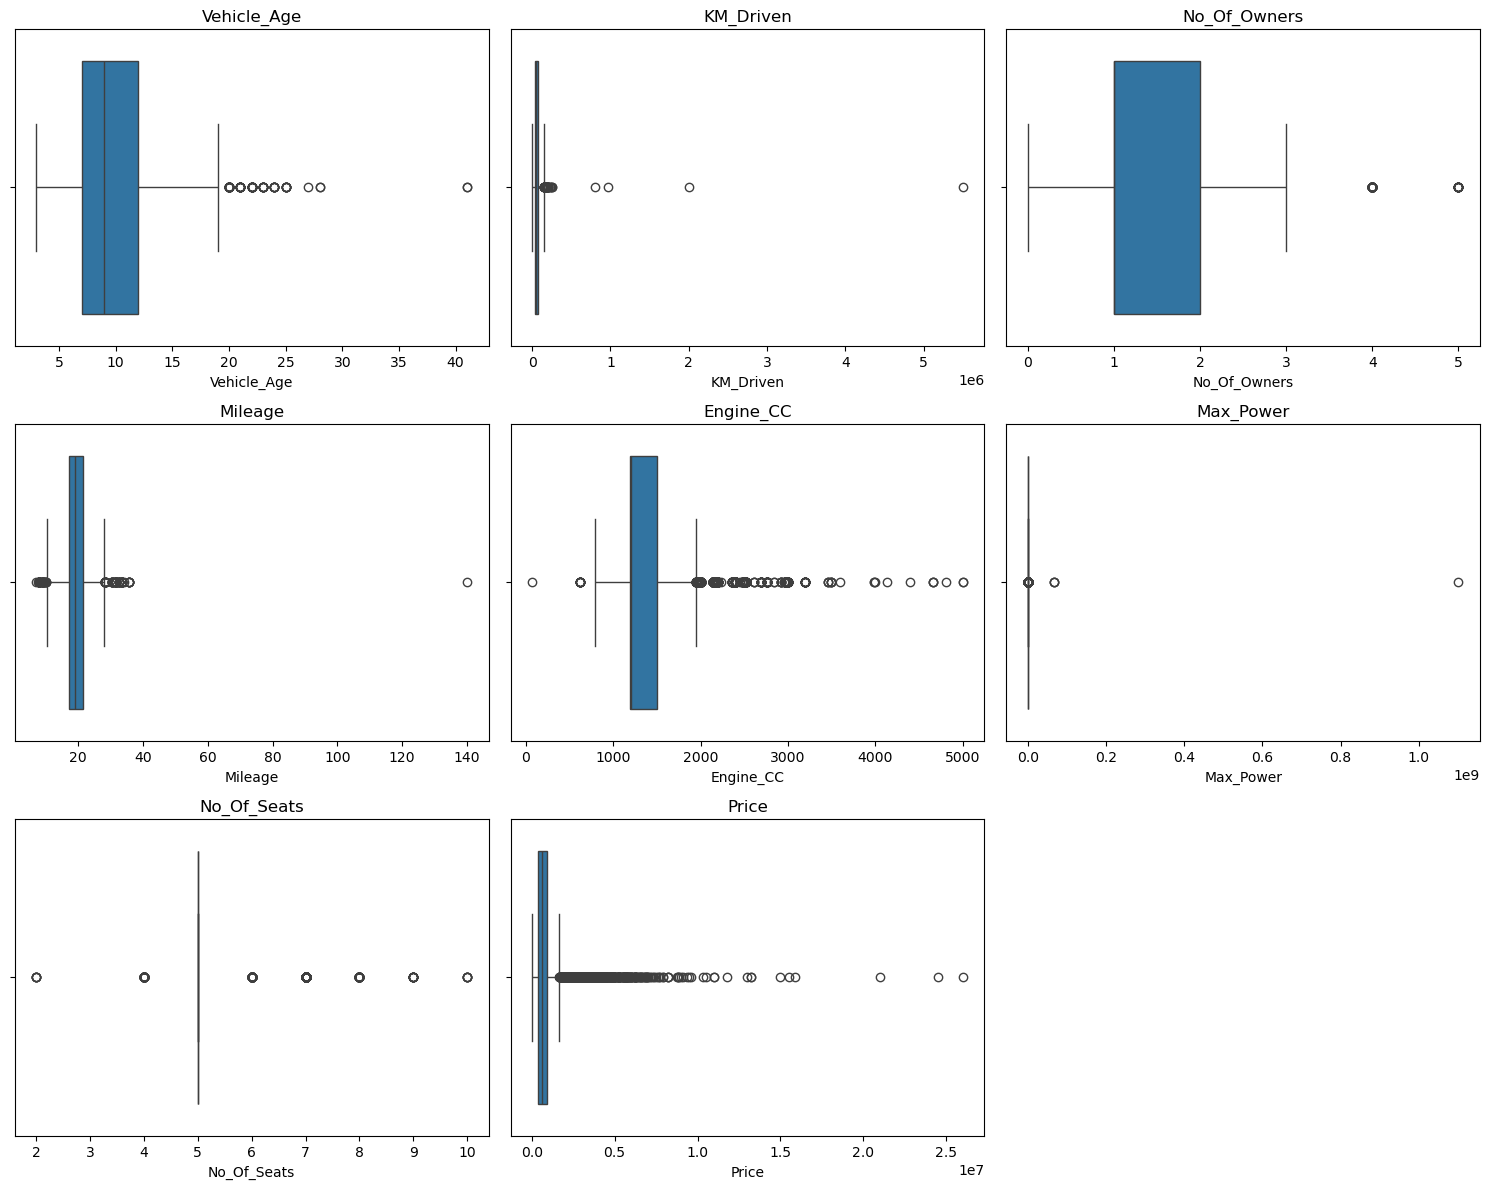

In [47]:
# Using boxplot to identify outliers
plt.figure(figsize=(15,12))
for i,col in enumerate(numerical_features,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [48]:
## Capping(winsorization)
def cap_outlier_iqr(df,column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    
    return df

In [49]:
# Apply only to important columns
cols_to_cap = ['KM_Driven','Mileage','Engine_CC','Max_Power']

for col in cols_to_cap:
    df = cap_outlier_iqr(df,col)

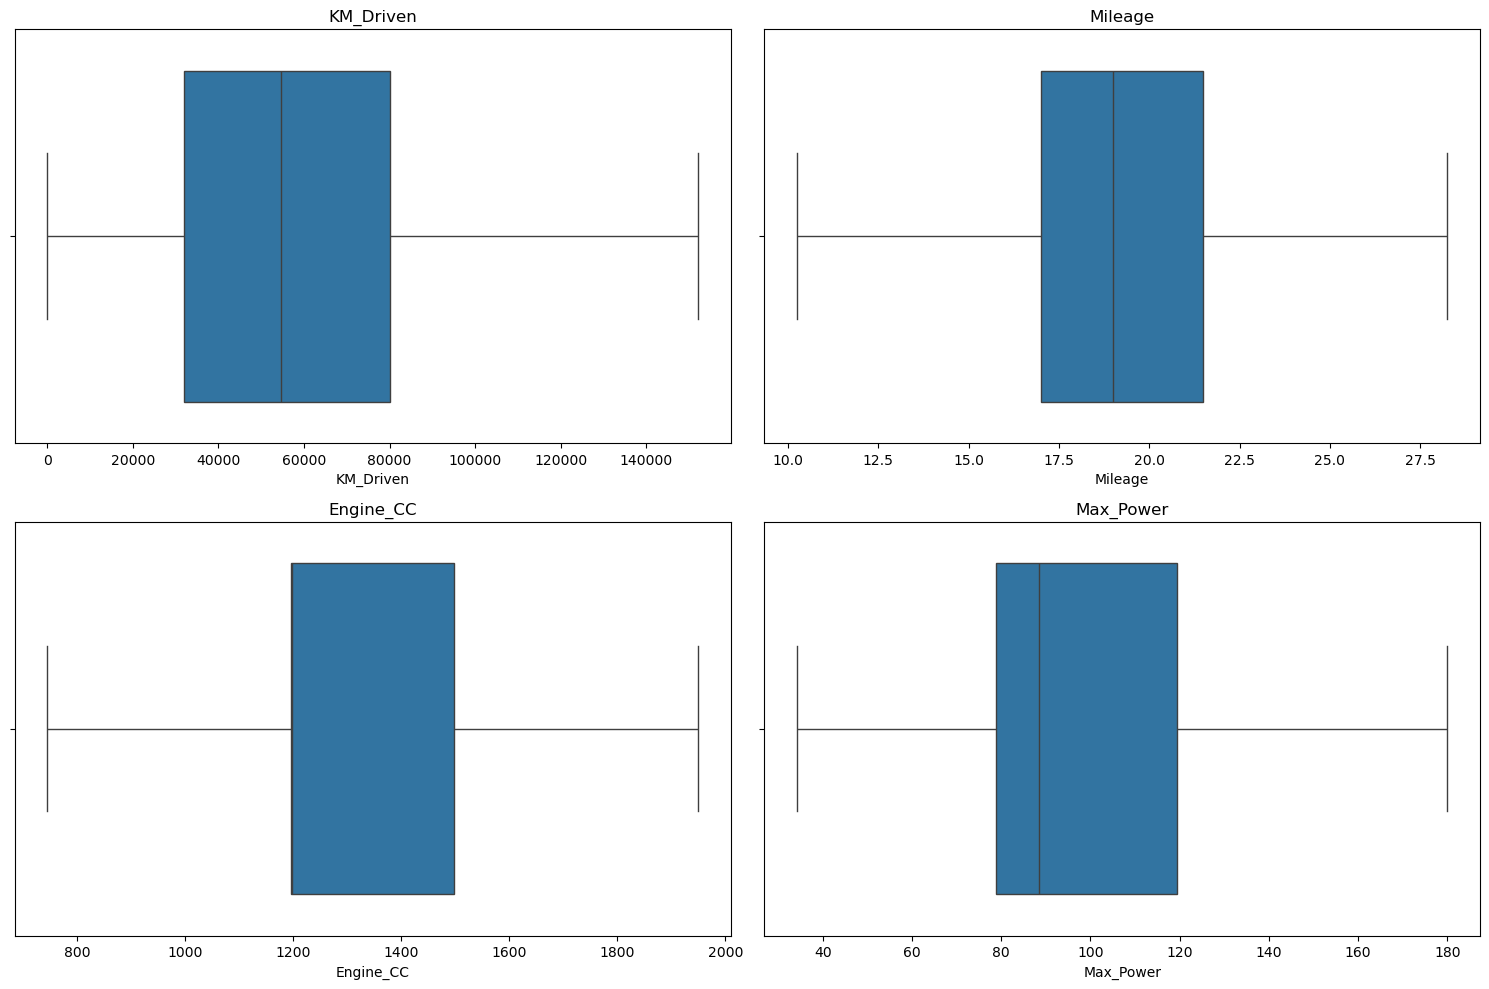

In [50]:
plt.figure(figsize=(15,10))
for i,col in enumerate(cols_to_cap,1):
    plt.subplot(2,2,i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [51]:
# Create a duplicate dataset and use log(1 + x) computation in 'Price' column
df_log = df.copy()

In [52]:
# Log transformation for price column
df_log['Price'] = np.log1p(df_log['Price'])

In [53]:
# To see the difference between price and log price column
pd.concat([df['Price'],df_log['Price']],axis=1,keys=['Price','Log_Price'])

,Price,Log_Price
0,400000,12.899222
1,811000,13.606025
2,585000,13.279369
3,462000,13.043322
4,790000,13.579789
...,...,...
8364,509999,13.142166
8365,180000,12.100718
8366,550000,13.217675
8367,140000,11.849405


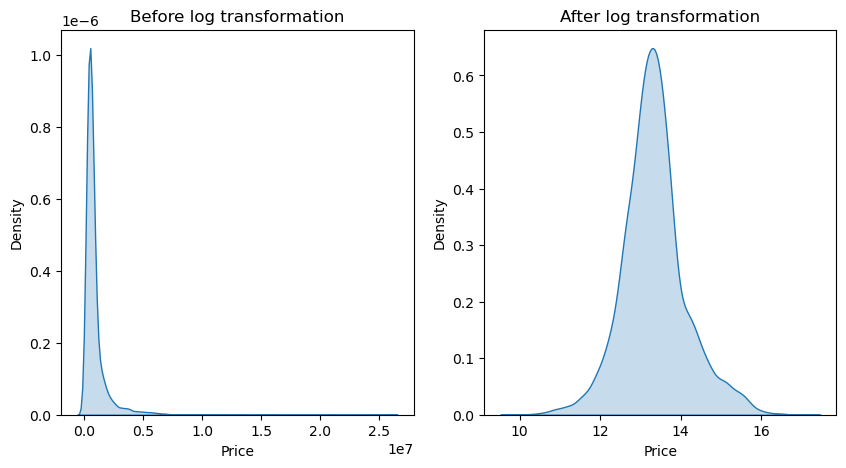

In [54]:
# Using kde plot to see the distribution of the 'Price' column
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.kdeplot(df['Price'], shade=True)
plt.title("Before log transformation")

plt.subplot(1,2,2)
sns.kdeplot(df_log['Price'], shade=True)
plt.title("After log transformation")
plt.show()

In [55]:
# To save cleaned dataframe
df_log.to_csv("cleaned_dataset.csv", index=False)

# Exploratory Data Analysis (EDA):

## 1) Univariate Analysis:

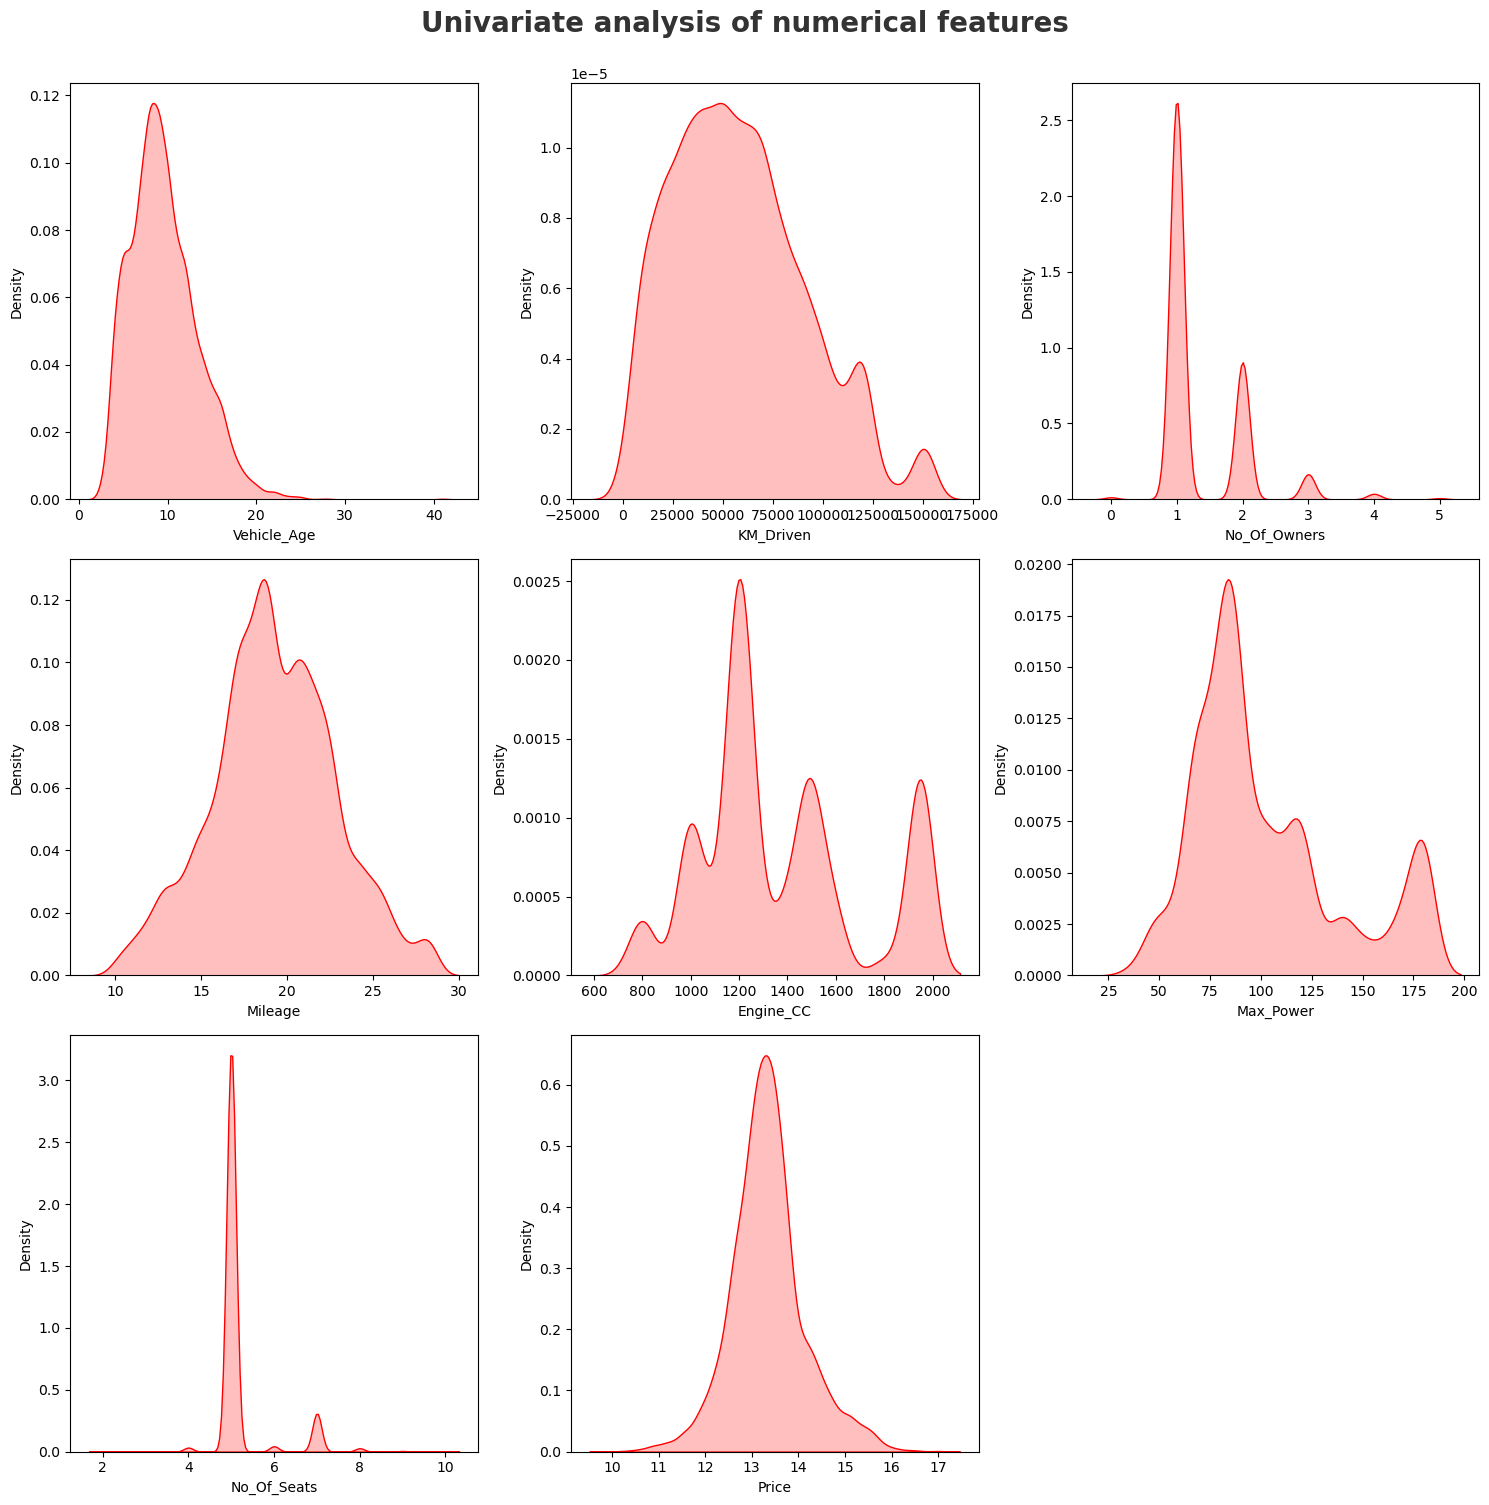

In [56]:
# Numerical features:
plt.figure(figsize=(15,15))
plt.suptitle('Univariate analysis of numerical features', fontsize=20, fontweight='bold', alpha=0.8, y=1.0)

for i in range(0, len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.kdeplot(x=df_log[numerical_features[i]],shade=True, color='r')
    plt.xlabel(numerical_features[i])
    
plt.tight_layout()
plt.show()

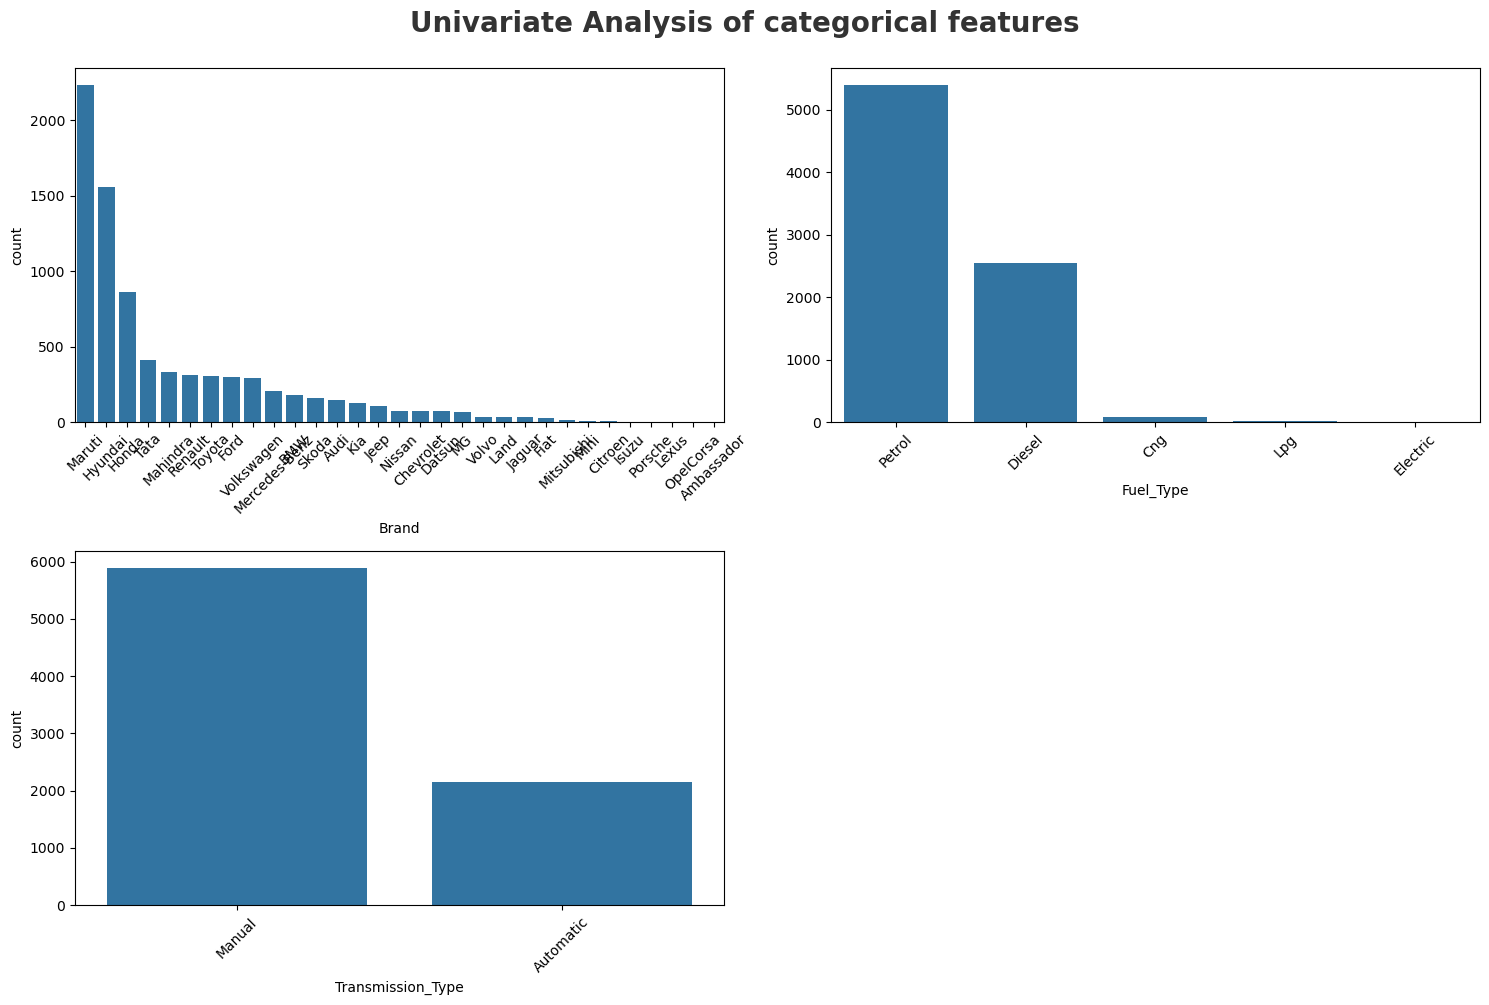

In [57]:
# Categorical features
plt.figure(figsize=(15,10))
plt.suptitle("Univariate Analysis of categorical features", fontsize=20, fontweight='bold', alpha=0.8, y=1.0)

cat1 = ['Brand','Fuel_Type','Transmission_Type']

for i in range(0, len(cat1)):
    order = df_log[cat1[i]].value_counts().index
    
    plt.subplot(2,2,i+1)
    sns.countplot(x=df_log[cat1[i]], order=order)
    plt.xlabel(cat1[i])
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2) Bivariate Analysis:

In [58]:
# Num of continuous features
continuous_features = [feature for feature in numerical_features if len(df[feature].unique())>=10]
continuous_features

['Vehicle_Age', 'KM_Driven', 'Mileage', 'Engine_CC', 'Max_Power', 'Price']

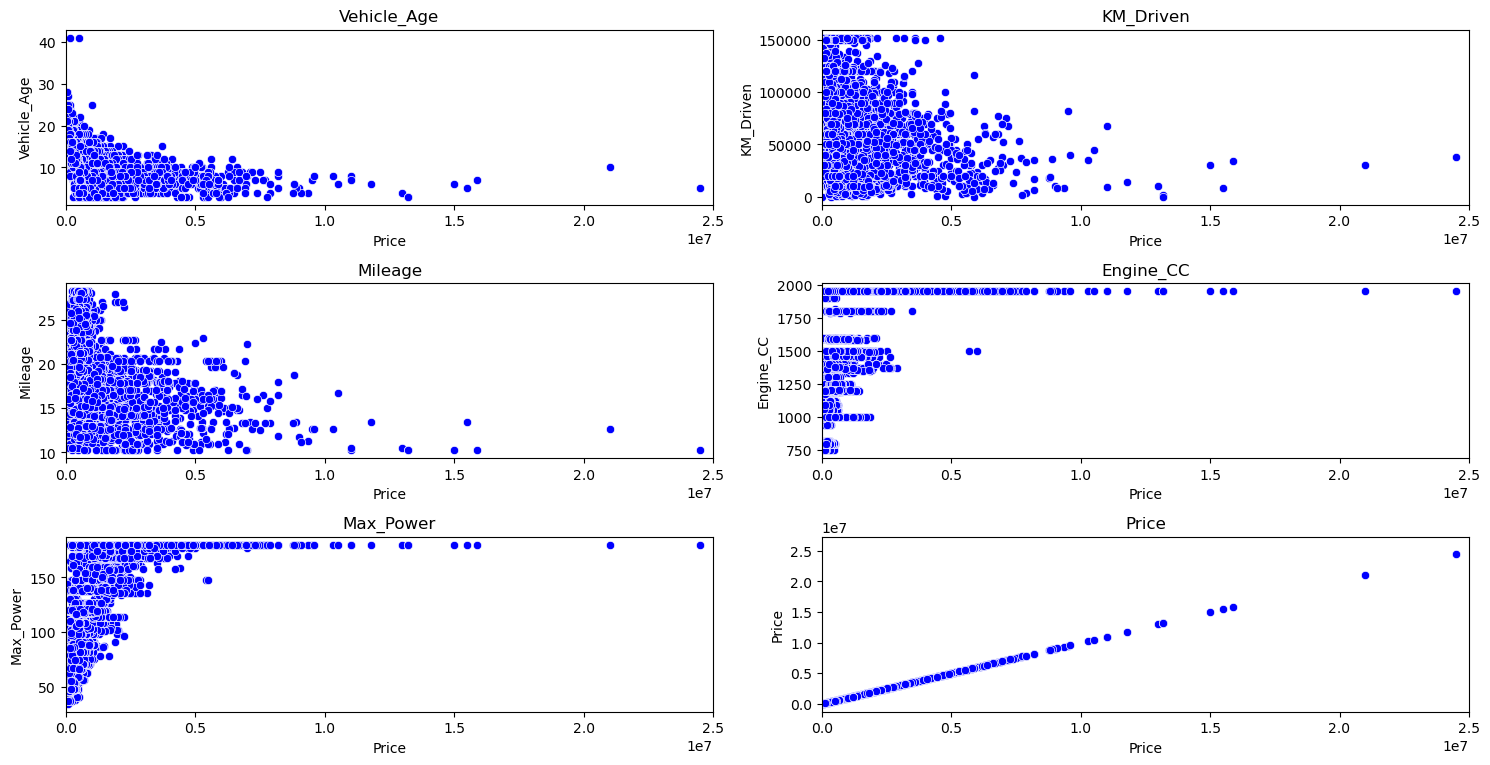

In [59]:
fig = plt.figure(figsize=(15,20))

for i in range(0, len(continuous_features)):
    ax = plt.subplot(8,2,i+1)
    sns.scatterplot(data=df, x='Price', y=continuous_features[i], color='b')
    plt.xlim(0,2_50_00_000)
    plt.title(continuous_features[i])
    
plt.tight_layout()
plt.show()

## 3) Multivariate Analysis

In [60]:
# Check multicollinearity in numerical features
df_log[numerical_features].corr()

,Vehicle_Age,KM_Driven,No_Of_Owners,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price
Vehicle_Age,1.000000,0.537502,0.375423,-0.129312,0.050172,-0.067212,0.001791,-0.590043
KM_Driven,0.537502,1.000000,0.265276,0.000022,0.167822,0.021373,0.136652,-0.281475
No_Of_Owners,0.375423,0.265276,1.000000,-0.085383,0.051893,0.006224,0.014385,-0.245805
Mileage,-0.129312,0.000022,-0.085383,1.000000,-0.585428,-0.608867,-0.332106,-0.346782
Engine_CC,0.050172,0.167822,0.051893,-0.585428,1.000000,0.850309,0.366289,0.609329
Max_Power,-0.067212,0.021373,0.006224,-0.608867,0.850309,1.000000,0.211825,0.703593
No_Of_Seats,0.001791,0.136652,0.014385,-0.332106,0.366289,0.211825,1.000000,0.180988
Price,-0.590043,-0.281475,-0.245805,-0.346782,0.609329,0.703593,0.180988,1.000000


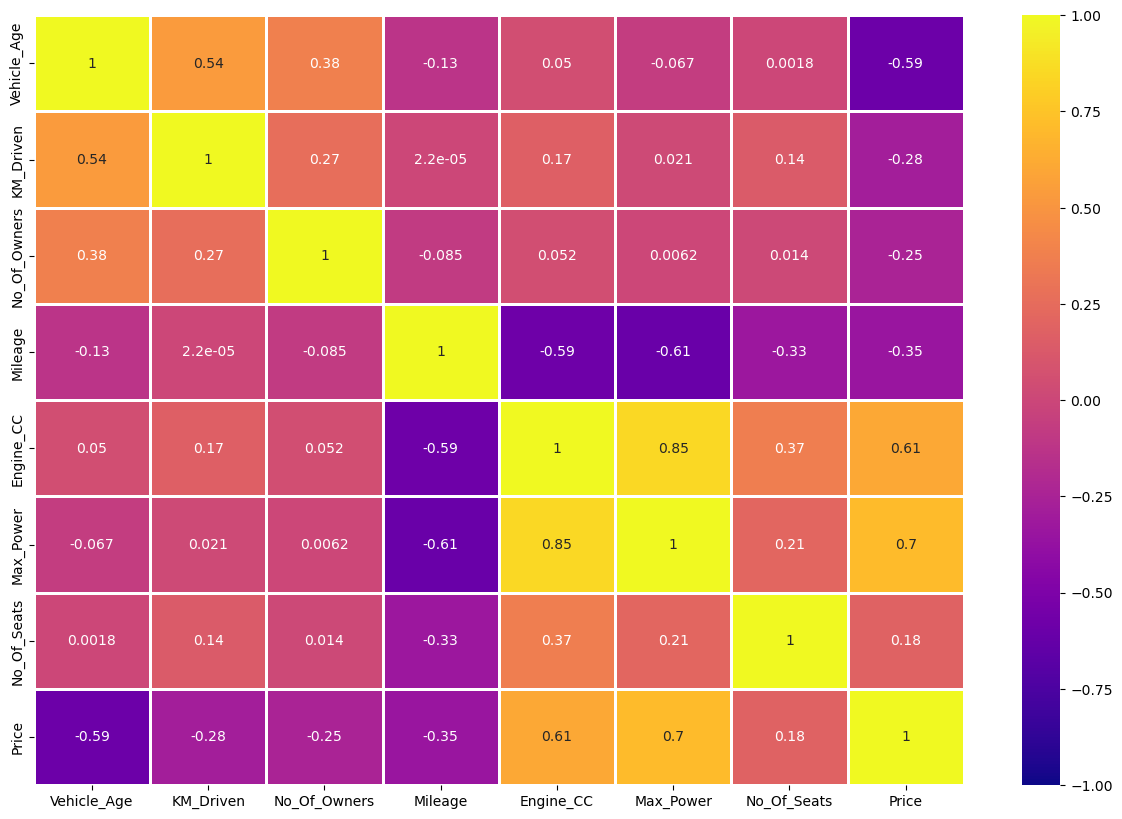

In [61]:
plt.figure(figsize=(15,10))
sns.heatmap(data=df_log[numerical_features].corr(), annot=True, cmap='plasma', vmin=-1, vmax=1, linecolor='white', linewidth=2)
plt.show()

# Insights from Data Visualization:

## Selling price distribution(target feature distribution)

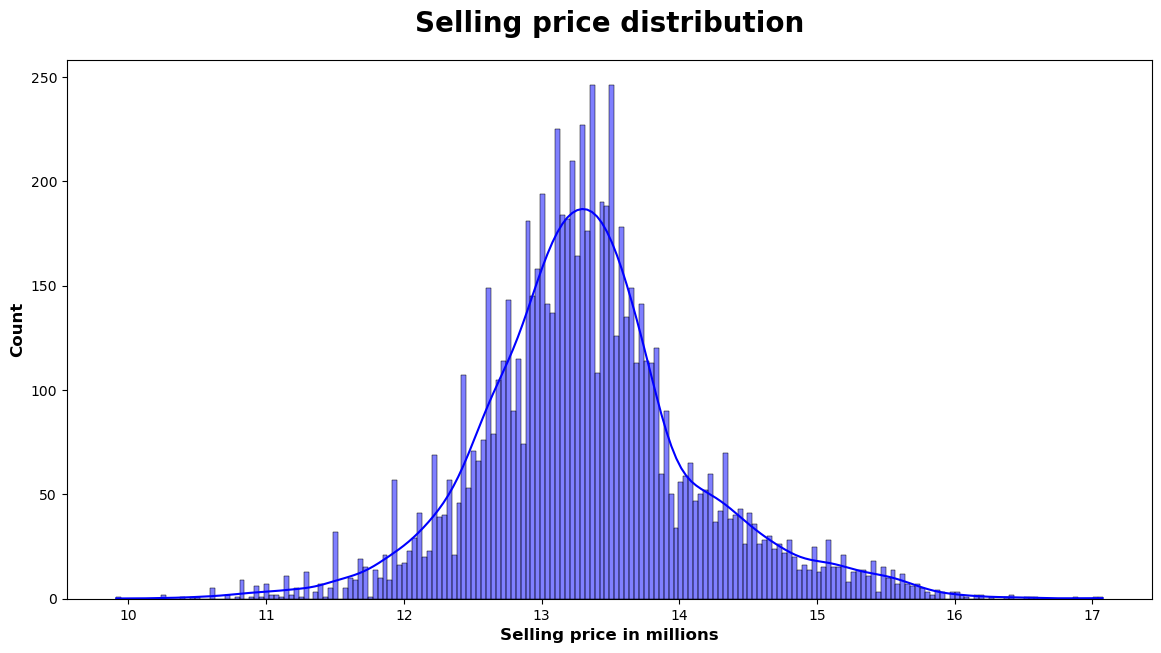

In [62]:
plt.subplots(figsize=(14,7))
sns.histplot(df_log.Price, bins=200, kde=True, color='b')
plt.title("Selling price distribution", weight='bold', fontsize=20, pad=20)
plt.ylabel("Count", weight='bold', fontsize=12)
plt.xlabel("Selling price in millions", weight='bold', fontsize=12)
plt.show()

## Top 10 sold cars

In [63]:
print("Top 10 sold cars:")
df_log.Car_Name.value_counts()[0:10]

Top 10 sold cars:


Car_Name
Honda City            370
Maruti Swift          348
Hyundai i20           331
Maruti Baleno         295
Hyundai Grand i10     260
Maruti Swift Dzire    253
Maruti Wagon R        249
Hyundai i10           183
Hyundai Verna         182
Honda Amaze           175
Name: count, dtype: int64

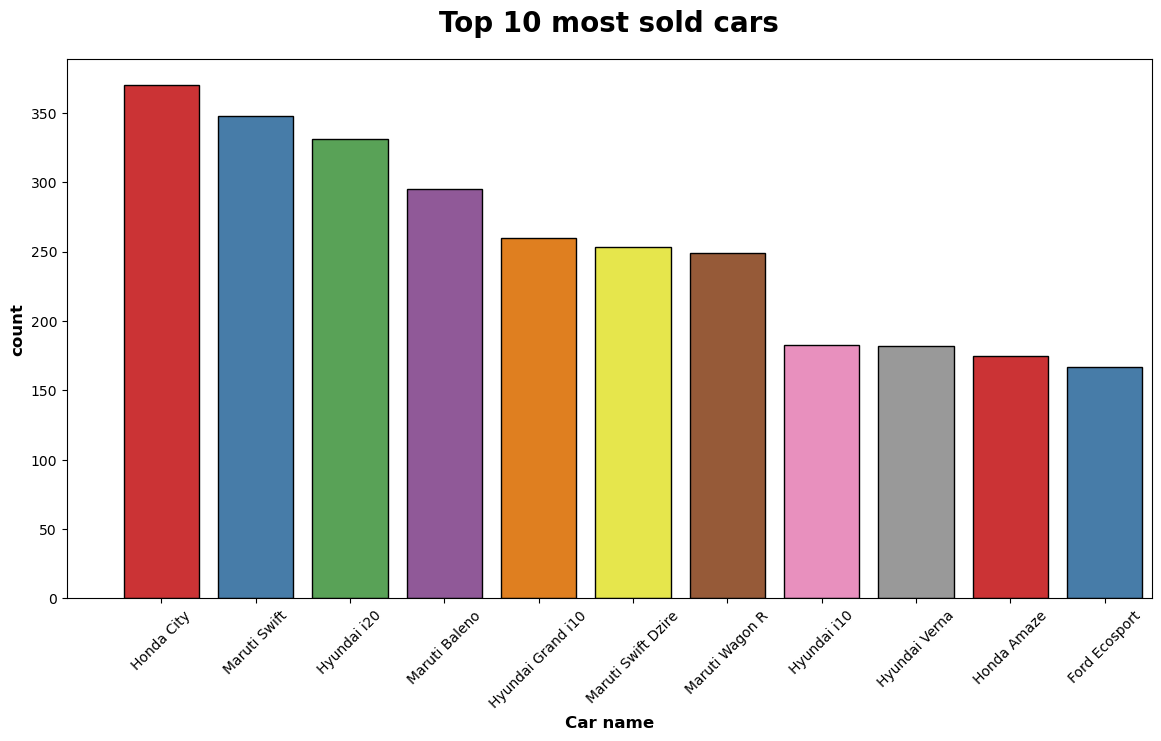

In [64]:
plt.subplots(figsize=(14,7))
sns.countplot(x='Car_Name', data=df, ec="black", palette='Set1', order=df['Car_Name'].value_counts().index)
plt.title("Top 10 most sold cars", weight='bold', fontsize=20, pad=20)
plt.xlabel("Car name", weight='bold', fontsize=12)
plt.ylabel("count", weight='bold', fontsize=12)
plt.xticks(rotation=45)
plt.xlim(-1,10.5)
plt.show()

In [65]:
# Check mean price of Honda City which is most sold
honda_city = df[df['Car_Name'] == 'Honda City']['Price'].mean()
print(f"The mean price of Honda City is {honda_city:.2f} rupees")

The mean price of Honda City is 698310.75 rupees


## Top 10 sold brand 

In [66]:
print("Top 10 sold brands:")
df_log.Brand.value_counts()[0:10]

Top 10 sold brands:


Brand
Maruti           2236
Hyundai          1559
Honda             863
Tata              410
Mahindra          334
Renault           312
Toyota            309
Ford              303
Volkswagen        292
Mercedes-Benz     210
Name: count, dtype: int64

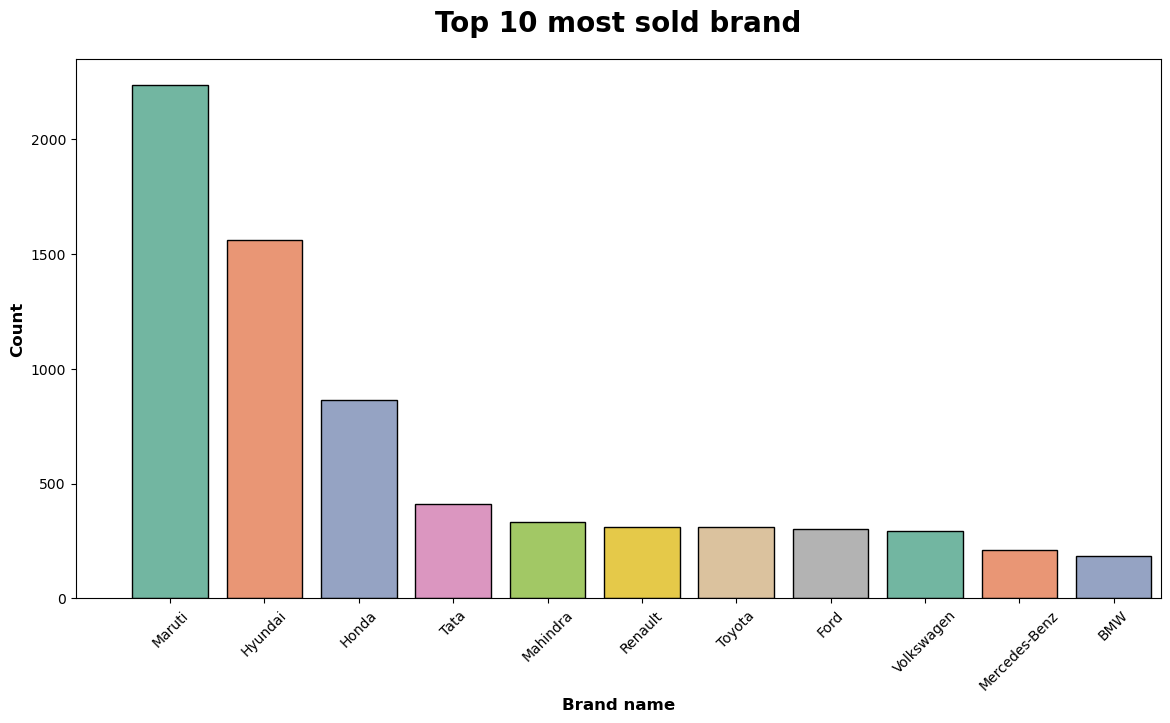

In [67]:
plt.subplots(figsize=(14,7))
sns.countplot(x='Brand', data=df, ec='black', palette='Set2', order=df['Brand'].value_counts().index)
plt.title("Top 10 most sold brand", weight='bold', fontsize=20, pad=20)
plt.xlabel("Brand name", weight='bold', fontsize=12)
plt.ylabel("Count", weight='bold', fontsize=12)
plt.xlim(-1,10.5)
plt.xticks(rotation=45)
plt.show()

In [68]:
# Check the mean price of maruti brand which is most sold
maruti_mean = df[df['Brand']=='Maruti']['Price'].mean()
print(f"The mean price of Maruti is {maruti_mean:.2f} rupees")

The mean price of Maruti is 506170.52 rupees


## Costlier brand

In [69]:
brand_cos = df.groupby('Brand').Price.max()
brand_cos = brand_cos.to_frame().sort_values('Price', ascending=False)[0:10]
brand_cos

,Price
Brand,
Land,26000000
Mercedes-Benz,24500000
Porsche,15000000
BMW,13000000
Audi,9100000
Lexus,8800000
Volvo,8200000
Jaguar,6400000
Jeep,6250000


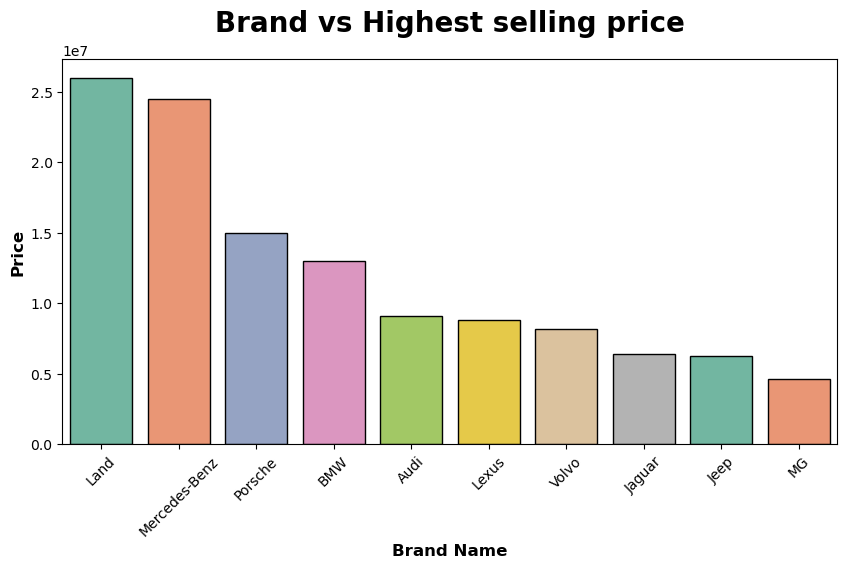

In [70]:
plt.subplots(figsize=(10,5))
sns.barplot(x=brand_cos.index, y=brand_cos.Price, ec='black', palette='Set2')
plt.title("Brand vs Highest selling price", weight='bold', fontsize=20, pad=20)
plt.xlabel("Brand Name", weight='bold', fontsize=12)
plt.ylabel("Price", weight='bold', fontsize=12)
plt.xticks(rotation=45)
plt.show()

## Costlier Car_Name

In [71]:
car_cos = df.groupby('Car_Name').Price.max()
car_cos = car_cos.to_frame().sort_values('Price', ascending=False)[0:10]
car_cos

,Price
Car_Name,
Land Rover Range Rover,26000000
Mercedes-Benz G,24500000
Mercedes-Benz AMG GT,21000000
Mercedes-Benz S-Class,15900000
Porsche 911,15000000
Land Rover Defender,13200000
BMW X7,13000000
BMW 7 Series,10500000
Land Rover Range Rover Sport,10300000


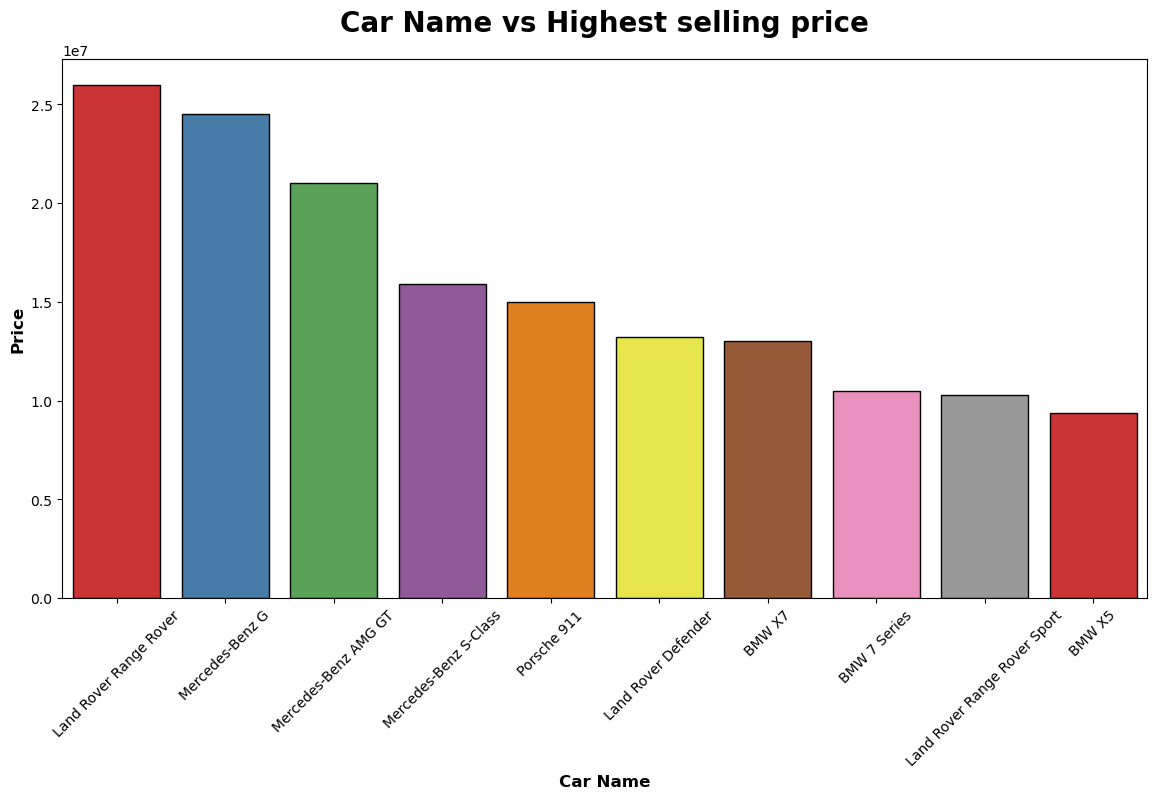

In [72]:
plt.subplots(figsize=(14,7))
sns.barplot(x=car_cos.index, y=car_cos.Price, ec='black', palette='Set1')
plt.title("Car Name vs Highest selling price", weight='bold', fontsize=20, pad=20)
plt.ylabel("Price", weight='bold', fontsize=12)
plt.xlabel("Car Name", weight='bold', fontsize=12)
plt.xticks(rotation=45)
plt.show()

## Most mileage car brand 

In [73]:
mos_mileage = df.groupby('Brand')['Mileage'].mean().sort_values(ascending=False).head(15)
mos_mileage

Brand
Maruti        21.901431
Datsun        21.265405
Renault       21.015962
Lexus         19.692500
Tata          19.686488
Nissan        19.276753
Hyundai       19.192412
Citroen       18.950000
Honda         18.807509
Chevrolet     18.643289
Ford          18.523960
Volkswagen    18.252055
BMW           17.610710
Skoda         17.459193
Kia           17.444885
Name: Mileage, dtype: float64

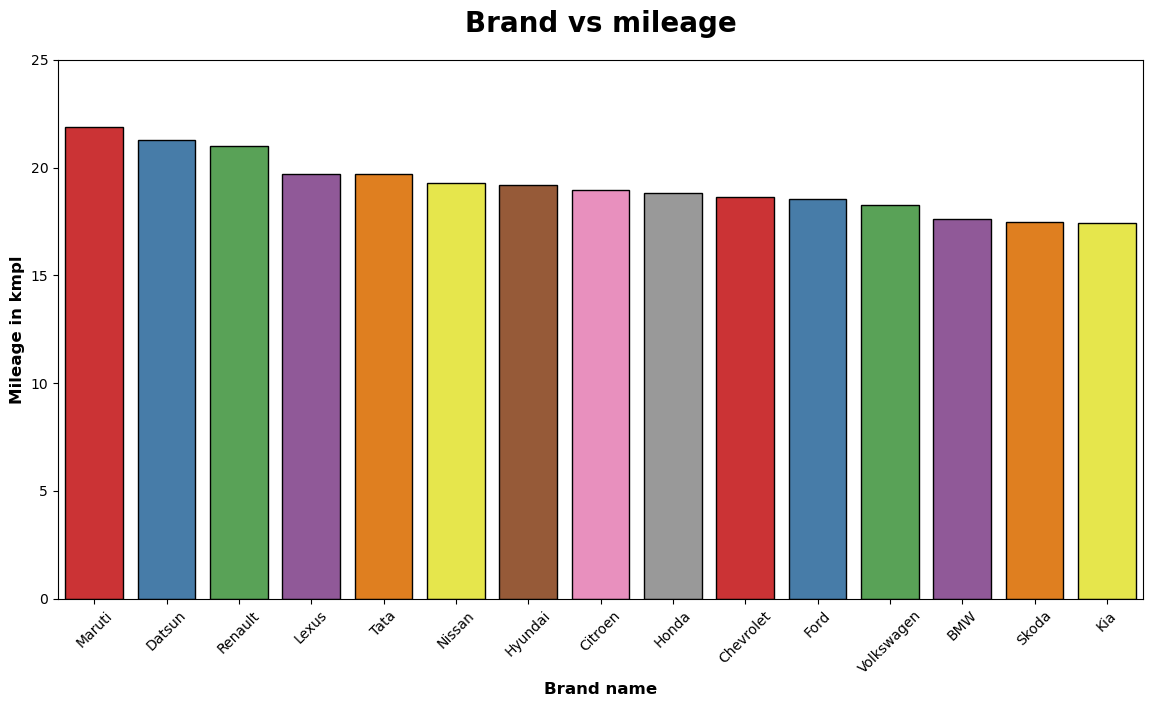

In [74]:
plt.subplots(figsize=(14,7))
sns.barplot(x=mos_mileage.index, y=mos_mileage.values, ec='black', palette='Set1')
plt.title("Brand vs mileage", weight='bold', fontsize=20, pad=20)
plt.xlabel("Brand name", weight='bold', fontsize=12)
plt.ylabel("Mileage in kmpl", weight='bold', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0,25)
plt.show()

## Most mileage car name

In [75]:
mos_mileage_car = df.groupby('Car_Name')['Mileage'].mean().sort_values(ascending=False).head(10)
mos_mileage_car

Car_Name
Mahindra e2o Plus          28.250000
Honda City Hybrid          26.500000
Tata Nano                  25.672727
Maruti Celerio             24.467171
Maruti Alto K10            23.725476
Tata Tiago                 23.103437
Renault Pulse              23.080000
Renault KWID               23.033933
Maruti Swift Dzire Tour    23.021429
Tata Bolt                  22.950000
Name: Mileage, dtype: float64

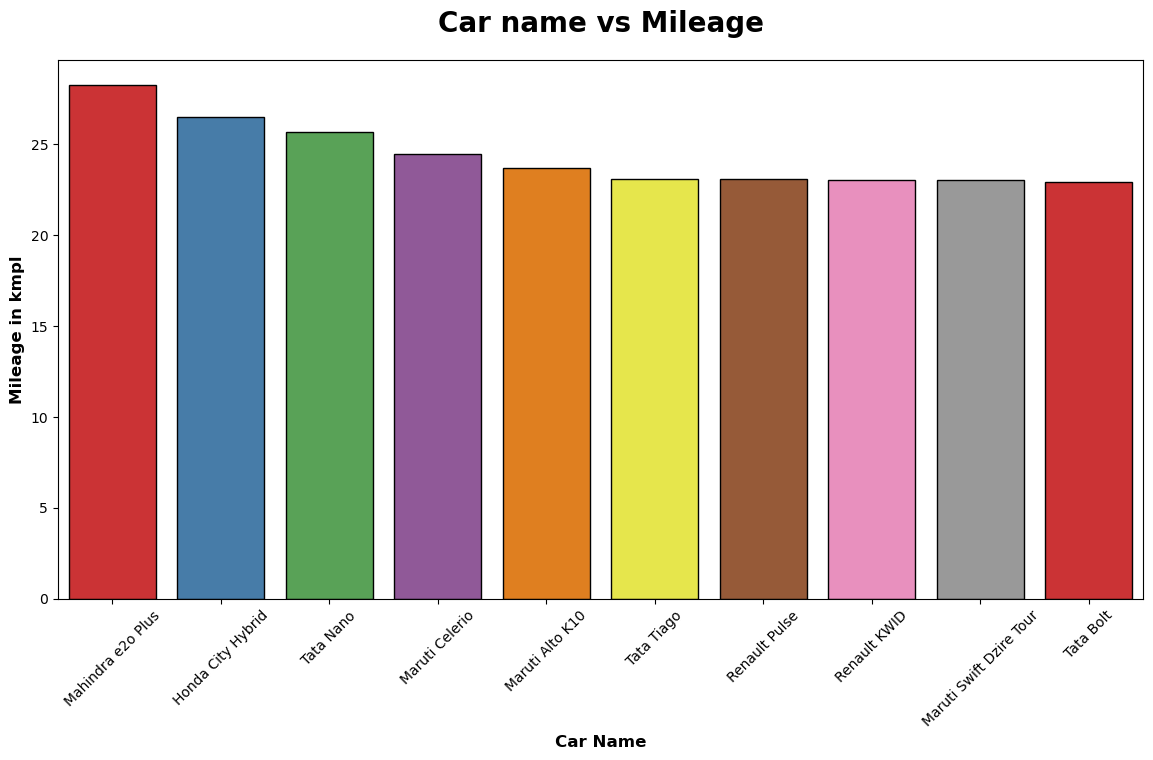

In [76]:
plt.subplots(figsize=(14,7))
sns.barplot(x=mos_mileage_car.index, y=mos_mileage_car.values, ec='black', palette='Set1')
plt.title("Car name vs Mileage", weight='bold', fontsize=20, pad=20)
plt.xlabel("Car Name", weight='bold', fontsize=12)
plt.ylabel("Mileage in kmpl", weight='bold', fontsize=12)
plt.xticks(rotation=45)
plt.show()

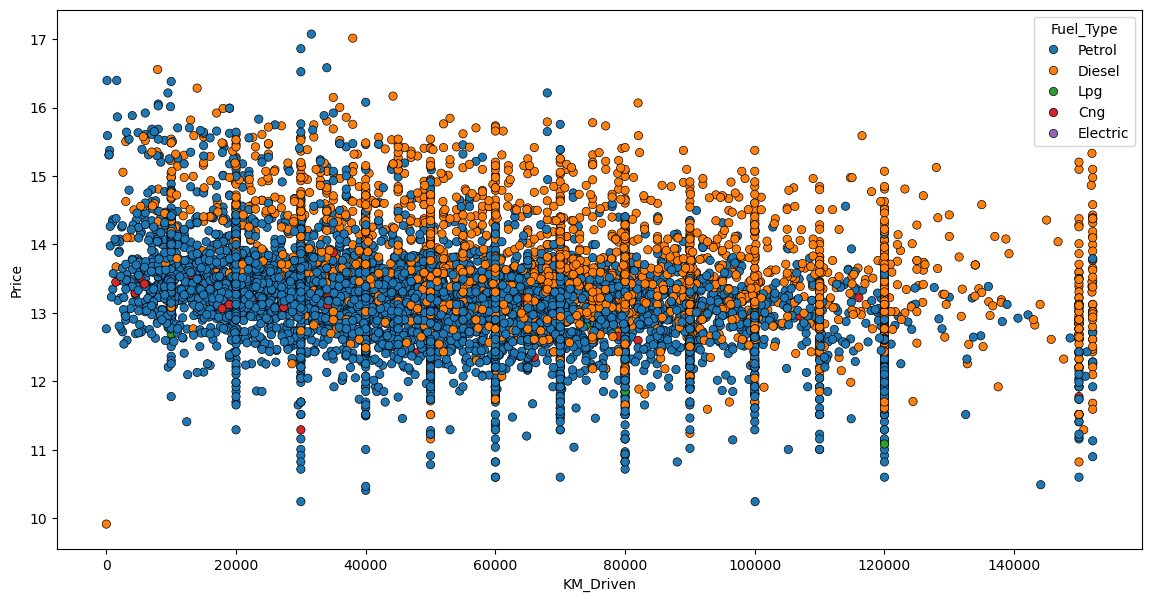

In [77]:
## Kilometers driven vs selling price
plt.subplots(figsize=(14,7))
sns.scatterplot(x='KM_Driven', y='Price', data=df_log, ec='black', color='b', hue='Fuel_Type')
plt.show()

In [78]:
## Fuel_Type VS Price
fuel = df.groupby('Fuel_Type')['Price'].median().sort_values(ascending=False)
fuel.to_frame()

,Price
Fuel_Type,
Diesel,800000.0
Petrol,545000.0
Cng,500000.0
Electric,459999.0
Lpg,220000.0


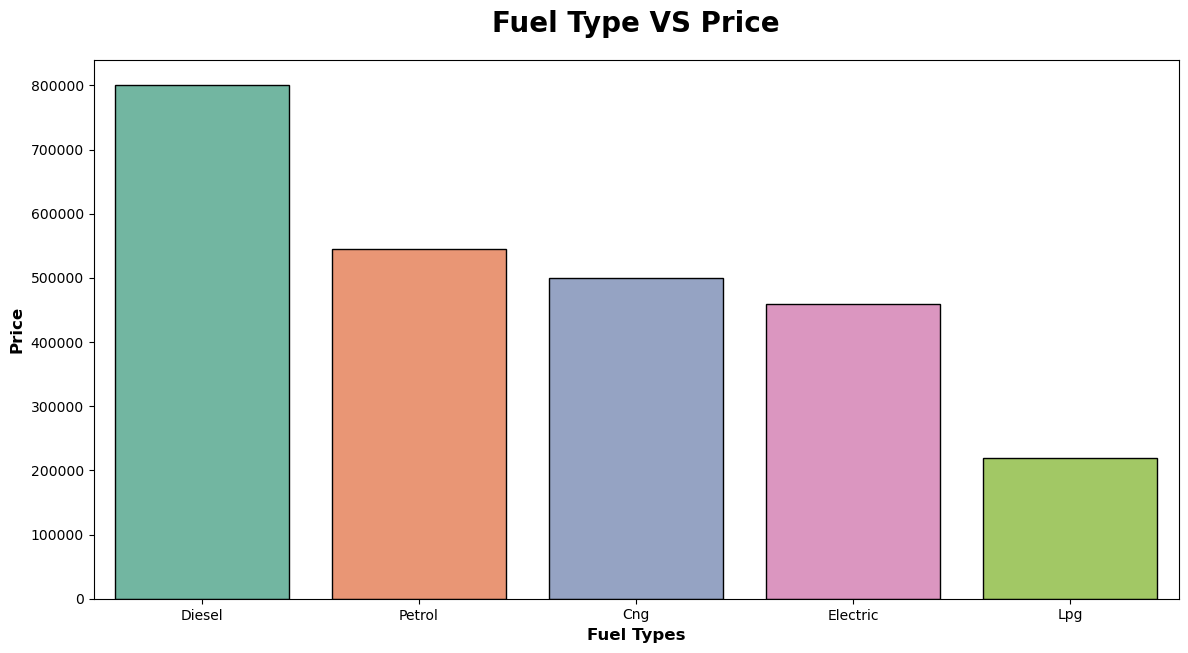

In [79]:
plt.subplots(figsize=(14,7))
sns.barplot(x=fuel.index, y=fuel.values, ec='black', palette='Set2')
plt.title("Fuel Type VS Price", weight='bold', fontsize=20, pad=20)
plt.xlabel("Fuel Types", weight='bold', fontsize=12)
plt.ylabel("Price", weight='bold', fontsize=12)
plt.show()

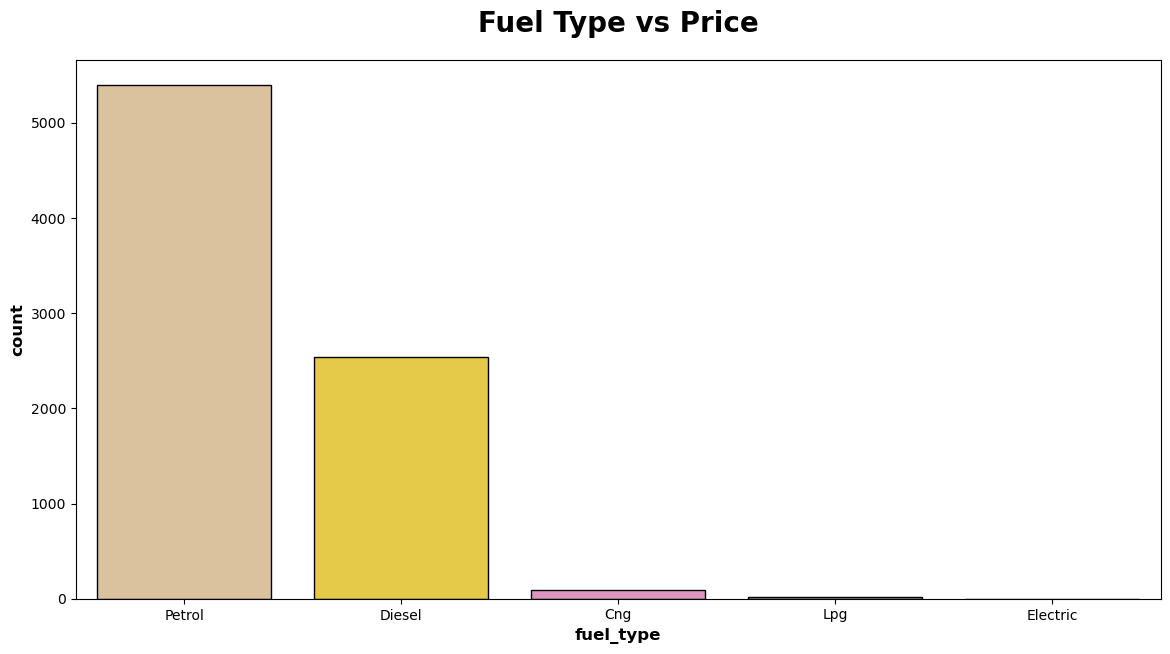

In [80]:
## Most sold fuel type
order = df['Fuel_Type'].value_counts().index
plt.subplots(figsize=(14,7))
sns.countplot(x=df.Fuel_Type, ec='black', palette='Set2_r', order=order)
plt.title("Fuel Type vs Price", weight='bold', fontsize=20, pad=20)
plt.ylabel("count", weight='bold', fontsize=12)
plt.xlabel("fuel_type", weight='bold', fontsize=12)
plt.show()

In [81]:
# Fuel Type VS Mileage
fuel_mileage = df.groupby('Fuel_Type')['Mileage'].mean().sort_values(ascending=False)
fuel_mileage.to_frame()

,Mileage
Fuel_Type,
Electric,28.250000
Cng,26.026667
Diesel,19.440008
Petrol,19.024372
Lpg,16.846667


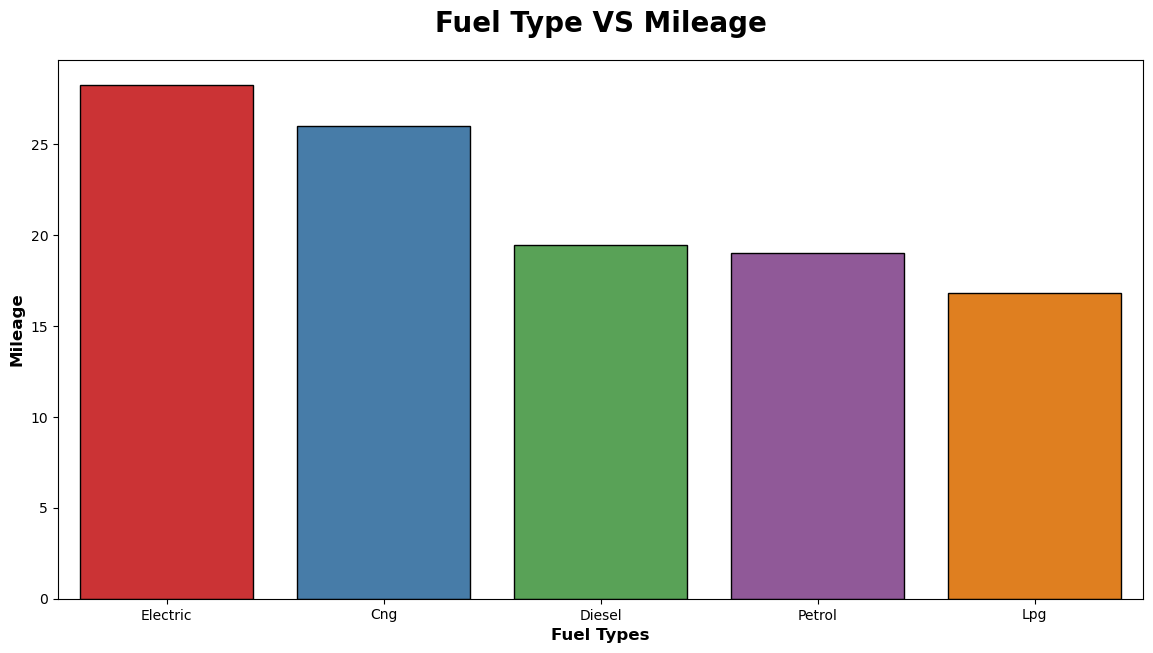

In [82]:
plt.subplots(figsize=(14,7))
sns.barplot(x=fuel_mileage.index, y=fuel_mileage.values, ec='black', palette='Set1')
plt.title("Fuel Type VS Mileage", weight='bold', fontsize=20, pad=20)
plt.xlabel("Fuel Types", weight='bold', fontsize=12)
plt.ylabel("Mileage", weight='bold', fontsize=12)
plt.show()

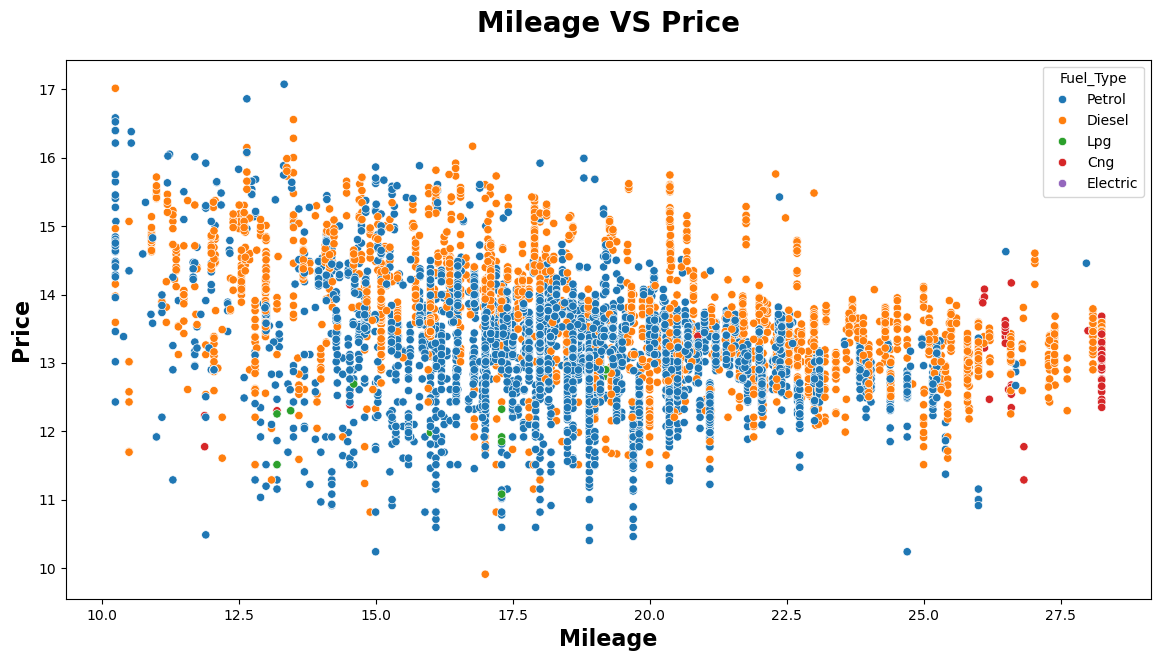

In [83]:
## Mileage vs Price
plt.subplots(figsize=(14,7))
sns.scatterplot(x='Mileage', y='Price', data=df_log, ec='white', color='b', hue='Fuel_Type')
plt.title("Mileage VS Price", weight='bold', fontsize=20, pad=20)
plt.xlabel("Mileage", weight='bold', fontsize=16)
plt.ylabel("Price", weight='bold', fontsize=16)
plt.show()

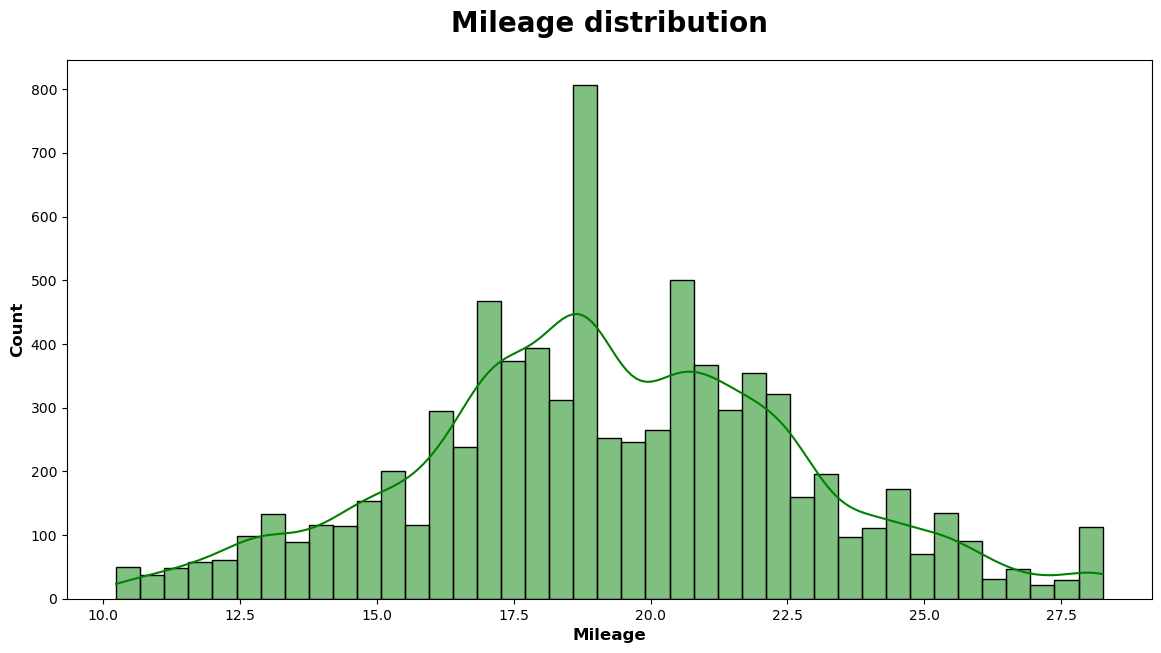

In [84]:
## Mileage distribution
plt.subplots(figsize=(14,7))
sns.histplot(x=df.Mileage, ec='black', color='g', kde=True)
plt.title("Mileage distribution", weight='bold', fontsize=20, pad=20)
plt.xlabel("Mileage", weight='bold', fontsize=12)
plt.ylabel("Count", weight='bold', fontsize=12)
plt.show()

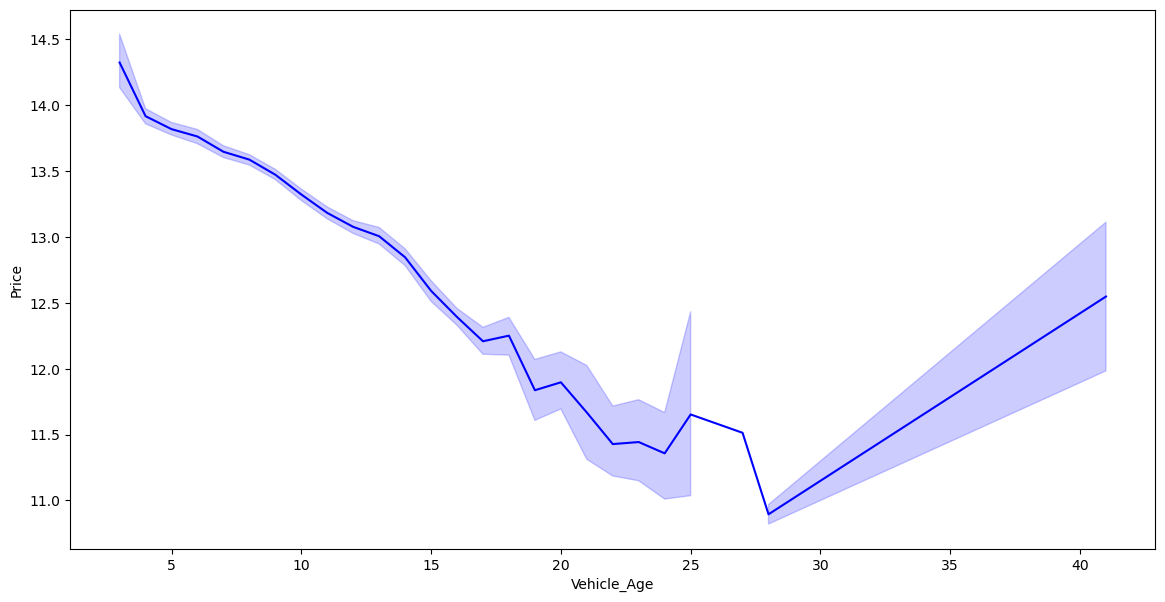

In [85]:
## Vehicle age vs Price
plt.subplots(figsize=(14,7))
sns.lineplot(x='Vehicle_Age', y='Price', data=df_log, color='b')
plt.show()

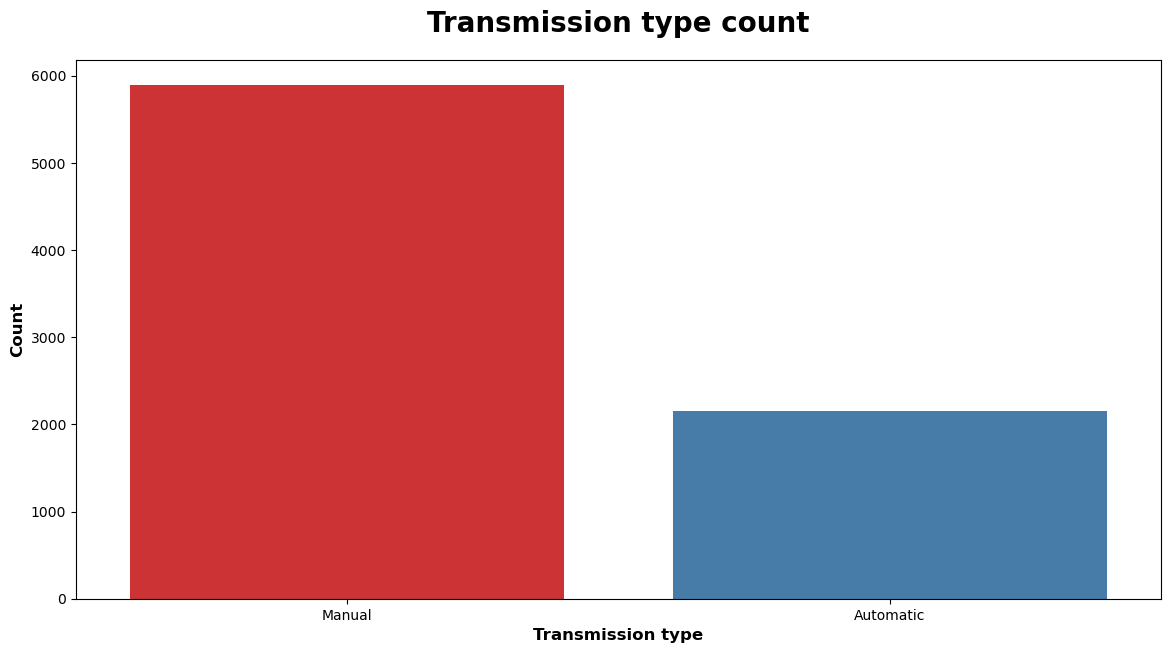

In [86]:
## Transmission type vs count
plt.subplots(figsize=(14,7))
sns.countplot(x=df.Transmission_Type, palette='Set1')
plt.title("Transmission type count", weight='bold', fontsize=20, pad=20)
plt.xlabel("Transmission type", weight='bold', fontsize=12)
plt.ylabel("Count", weight='bold', fontsize=12)
plt.show()

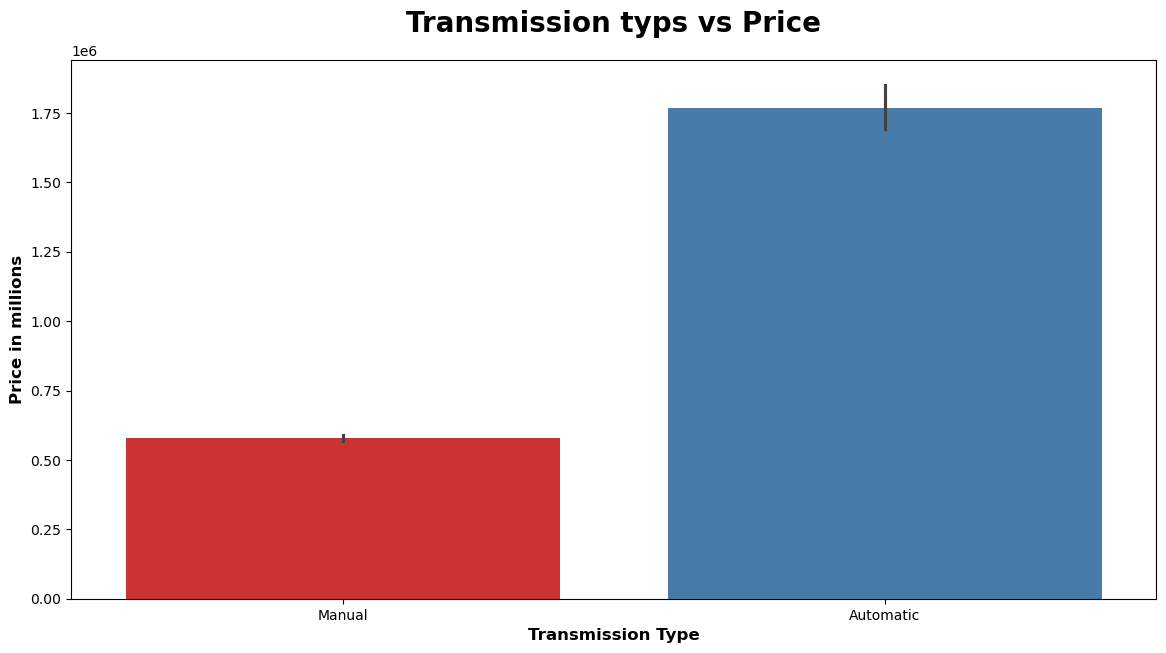

In [87]:
## Transmission type vs Price
plt.subplots(figsize=(14,7))
sns.barplot(x=df.Transmission_Type, y=df.Price, palette='Set1')
plt.title("Transmission typs vs Price", weight='bold', fontsize=20, pad=20)
plt.xlabel("Transmission Type", weight='bold', fontsize=12)
plt.ylabel("Price in millions", weight='bold', fontsize=12)
plt.show()

# Feature Engineering

In [88]:
# Removing unnecessary features
# Creating a copy of orginal dataframe
df_model = df_log.copy()
df_model

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Maruti Celerio,Maruti,Celerio,11,120000.0,3,Petrol,Manual,23.10,998.0,67.040,5,12.899222,bangalore
1,Ford Ecosport,Ford,Ecosport,8,32706.0,2,Petrol,Manual,17.00,1497.0,121.310,5,13.606025,bangalore
2,Tata Tiago,Tata,Tiago,8,11949.0,1,Petrol,Manual,23.84,1199.0,84.000,5,13.279369,bangalore
3,Hyundai Xcent,Hyundai,Xcent,12,17794.0,1,Petrol,Manual,19.10,1197.0,81.860,5,13.043322,bangalore
4,Maruti SX4 S Cross,Maruti,SX4 S Cross,11,60000.0,1,Diesel,Manual,23.65,1248.0,88.500,5,13.579789,bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8364,Maruti Celerio,Maruti,Celerio,4,10000.0,1,Petrol,Manual,25.24,998.0,65.710,5,13.142166,kolkata
8365,Maruti Alto 800,Maruti,Alto 800,12,120000.0,1,Petrol,Manual,22.74,796.0,47.300,5,12.100718,kolkata
8366,Mercedes-Benz C-Class,Mercedes-Benz,C-Class,15,50000.0,3,Petrol,Automatic,11.74,1796.0,180.025,5,13.217675,kolkata
8367,Maruti Ritz,Maruti,Ritz,14,40000.0,1,Petrol,Manual,18.50,1197.0,85.800,5,11.849405,kolkata


In [89]:
# Dropping Car_Name feature
df_model = df_model.drop(labels=['Car_Name'], axis=1)
df_model

,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Maruti,Celerio,11,120000.0,3,Petrol,Manual,23.10,998.0,67.040,5,12.899222,bangalore
1,Ford,Ecosport,8,32706.0,2,Petrol,Manual,17.00,1497.0,121.310,5,13.606025,bangalore
2,Tata,Tiago,8,11949.0,1,Petrol,Manual,23.84,1199.0,84.000,5,13.279369,bangalore
3,Hyundai,Xcent,12,17794.0,1,Petrol,Manual,19.10,1197.0,81.860,5,13.043322,bangalore
4,Maruti,SX4 S Cross,11,60000.0,1,Diesel,Manual,23.65,1248.0,88.500,5,13.579789,bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8364,Maruti,Celerio,4,10000.0,1,Petrol,Manual,25.24,998.0,65.710,5,13.142166,kolkata
8365,Maruti,Alto 800,12,120000.0,1,Petrol,Manual,22.74,796.0,47.300,5,12.100718,kolkata
8366,Mercedes-Benz,C-Class,15,50000.0,3,Petrol,Automatic,11.74,1796.0,180.025,5,13.217675,kolkata
8367,Maruti,Ritz,14,40000.0,1,Petrol,Manual,18.50,1197.0,85.800,5,11.849405,kolkata


In [90]:
# Creating feature matrix(independent variable) and target variable(dependent variable)
x = df_model.drop("Price", axis=1)
x 

,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Location
0,Maruti,Celerio,11,120000.0,3,Petrol,Manual,23.10,998.0,67.040,5,bangalore
1,Ford,Ecosport,8,32706.0,2,Petrol,Manual,17.00,1497.0,121.310,5,bangalore
2,Tata,Tiago,8,11949.0,1,Petrol,Manual,23.84,1199.0,84.000,5,bangalore
3,Hyundai,Xcent,12,17794.0,1,Petrol,Manual,19.10,1197.0,81.860,5,bangalore
4,Maruti,SX4 S Cross,11,60000.0,1,Diesel,Manual,23.65,1248.0,88.500,5,bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...
8364,Maruti,Celerio,4,10000.0,1,Petrol,Manual,25.24,998.0,65.710,5,kolkata
8365,Maruti,Alto 800,12,120000.0,1,Petrol,Manual,22.74,796.0,47.300,5,kolkata
8366,Mercedes-Benz,C-Class,15,50000.0,3,Petrol,Automatic,11.74,1796.0,180.025,5,kolkata
8367,Maruti,Ritz,14,40000.0,1,Petrol,Manual,18.50,1197.0,85.800,5,kolkata


In [91]:
y = df_model['Price']
y

0       12.899222
1       13.606025
2       13.279369
3       13.043322
4       13.579789
          ...    
8364    13.142166
8365    12.100718
8366    13.217675
8367    11.849405
8368    13.122365
Name: Price, Length: 8042, dtype: float64

In [92]:
# # Checking for important features
# from sklearn.ensemble import ExtraTreesRegressor

# model = ExtraTreesRegressor()
# model.fit(x,y)

In [93]:
# model.feature_importances_

In [94]:
# # Visualization for feature importance
# imp_feature = pd.Series(model.feature_importances_,index=x.columns)
# imp_feature.sort_values(ascending=False)

In [95]:
# imp_feature.nlargest(7).plot(kind='barh', color='red')
# plt.title("Important features", fontsize=16)
# plt.show()

# Model building and Evaluation

In [96]:
# Train test split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [97]:
# Remove 'Car_Name' in categorical feature and 'Price' in numerical feature
categorical_features.remove('Car_Name')
numerical_features.remove('Price')

In [98]:
# Using ColumnTransformer to encode categorical features and scaling the numerical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

In [99]:
x_train_final = preprocessor.fit_transform(x_train)
x_test_final = preprocessor.transform(x_test)

In [100]:
x_train_final

array([[ 0.        ,  0.        ,  0.        , ...,  0.69508345,
         0.53029378, -0.30879701],
       [ 0.        ,  0.        ,  0.        , ..., -0.34797509,
        -0.76467802, -0.30879701],
       [ 0.        ,  0.        ,  0.        , ...,  0.66771456,
         0.66444519, -0.30879701],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.39706672,
        -0.87418938,  2.73563393],
       [ 0.        ,  0.        ,  0.        , ...,  0.41227166,
        -0.09118318,  2.73563393],
       [ 0.        ,  0.        ,  0.        , ...,  1.78527728,
         2.13805739, -0.30879701]])

In [101]:
preprocessor.get_feature_names_out()

array(['cat__Brand_Audi', 'cat__Brand_BMW', 'cat__Brand_Chevrolet',
       'cat__Brand_Citroen', 'cat__Brand_Datsun', 'cat__Brand_Fiat',
       'cat__Brand_Ford', 'cat__Brand_Honda', 'cat__Brand_Hyundai',
       'cat__Brand_Isuzu', 'cat__Brand_Jaguar', 'cat__Brand_Jeep',
       'cat__Brand_Kia', 'cat__Brand_Land', 'cat__Brand_Lexus',
       'cat__Brand_MG', 'cat__Brand_Mahindra', 'cat__Brand_Maruti',
       'cat__Brand_Mercedes-Benz', 'cat__Brand_Mini',
       'cat__Brand_Mitsubishi', 'cat__Brand_Nissan',
       'cat__Brand_OpelCorsa', 'cat__Brand_Porsche', 'cat__Brand_Renault',
       'cat__Brand_Skoda', 'cat__Brand_Tata', 'cat__Brand_Toyota',
       'cat__Brand_Volkswagen', 'cat__Brand_Volvo', 'cat__Model_1 Series',
       'cat__Model_2 Series', 'cat__Model_3 DOOR', 'cat__Model_3 Series',
       'cat__Model_3 Series GT', 'cat__Model_3 Series Gran Limousine',
       'cat__Model_5 Series', 'cat__Model_6 Series',
       'cat__Model_7 Series', 'cat__Model_800', 'cat__Model_A Class',
    

In [102]:
x_train_final.shape

(6433, 315)

In [103]:
x_test_final.shape

(1609, 315)

In [104]:
# Importing libraries for model building
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score, r2_score


In [105]:
models = [LinearRegression,DecisionTreeRegressor, RandomForestRegressor,KNeighborsRegressor,XGBRegressor]
mse = []
rmse = []
evs = []
r_square_score = []

for model in models:
    regressor = model().fit(x_train_final,y_train)
    pred = regressor.predict(x_test_final)
    mse.append(mean_squared_error(y_true=y_test, y_pred=pred))
    rmse.append(np.sqrt(mean_squared_error(y_true=y_test, y_pred=pred)))
    evs.append(explained_variance_score(y_true=y_test, y_pred=pred))
    r_square_score.append(r2_score(y_true=y_test, y_pred=pred))

In [106]:
ml_model_df = pd.DataFrame({
    "model" : ['LinearRegression','DecisionTreeRegressor','RandomForestRegressor','KNeighborsRegressor','XGBRegressor'],
    "Mean Squared Error" : mse,
    "Root Mean Squared Error" : rmse,
    "Explained Variance Score" : evs,
    "R_Square Score(Accuracy)" : r_square_score
})
ml_model_df

,model,Mean Squared Error,Root Mean Squared Error,Explained Variance Score,R_Square Score(Accuracy)
0,LinearRegression,0.038597,0.196460,0.940087,0.939961
1,DecisionTreeRegressor,0.071221,0.266872,0.889406,0.889213
2,RandomForestRegressor,0.041160,0.202878,0.936285,0.935974
3,KNeighborsRegressor,0.061842,0.248681,0.903851,0.903802
4,XGBRegressor,0.034865,0.186721,0.946000,0.945766


In [107]:
ml_model_df.set_index("model", inplace=True)

In [108]:
ml_model_df.sort_values(by='R_Square Score(Accuracy)', ascending=False)

,Mean Squared Error,Root Mean Squared Error,Explained Variance Score,R_Square Score(Accuracy)
model,,,,
XGBRegressor,0.034865,0.186721,0.946000,0.945766
LinearRegression,0.038597,0.196460,0.940087,0.939961
RandomForestRegressor,0.041160,0.202878,0.936285,0.935974
KNeighborsRegressor,0.061842,0.248681,0.903851,0.903802
DecisionTreeRegressor,0.071221,0.266872,0.889406,0.889213


# Generating pickle file - saving trained models

In [109]:
import pickle

saved_models = []

for model_class in models:
    model = model_class()
    regressor = model.fit(x_train_final,y_train)
    # Save the trained model to a pickle file
    model_filename = f"{model_class.__name__}_model.pkl"
    with open(model_filename,'wb') as model_file:
        pickle.dump(regressor, model_file)
    saved_models.append(model_filename)

In [110]:
saved_models

['LinearRegression_model.pkl',
 'DecisionTreeRegressor_model.pkl',
 'RandomForestRegressor_model.pkl',
 'KNeighborsRegressor_model.pkl',
 'XGBRegressor_model.pkl']

In [111]:
pickle.dump(preprocessor,open("preprocessor.pkl",'wb'))

In [112]:
df_log.head(3)

,Car_Name,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Price,Location
0,Maruti Celerio,Maruti,Celerio,11,120000.0,3,Petrol,Manual,23.10,998.0,67.04,5,12.899222,bangalore
1,Ford Ecosport,Ford,Ecosport,8,32706.0,2,Petrol,Manual,17.00,1497.0,121.31,5,13.606025,bangalore
2,Tata Tiago,Tata,Tiago,8,11949.0,1,Petrol,Manual,23.84,1199.0,84.00,5,13.279369,bangalore


In [113]:
actual_price = np.expm1(df_log['Price'])
actual_price

0       400000.0
1       811000.0
2       585000.0
3       462000.0
4       790000.0
          ...   
8364    509999.0
8365    180000.0
8366    550000.0
8367    140000.0
8368    500000.0
Name: Price, Length: 8042, dtype: float64

In [114]:
print(f"{actual_price.mean():.2f}")

897294.29


In [115]:
df_log.columns

Index(['Car_Name', 'Brand', 'Model', 'Vehicle_Age', 'KM_Driven',
       'No_Of_Owners', 'Fuel_Type', 'Transmission_Type', 'Mileage',
       'Engine_CC', 'Max_Power', 'No_Of_Seats', 'Price', 'Location'],
      dtype='object')

In [116]:
x

,Brand,Model,Vehicle_Age,KM_Driven,No_Of_Owners,Fuel_Type,Transmission_Type,Mileage,Engine_CC,Max_Power,No_Of_Seats,Location
0,Maruti,Celerio,11,120000.0,3,Petrol,Manual,23.10,998.0,67.040,5,bangalore
1,Ford,Ecosport,8,32706.0,2,Petrol,Manual,17.00,1497.0,121.310,5,bangalore
2,Tata,Tiago,8,11949.0,1,Petrol,Manual,23.84,1199.0,84.000,5,bangalore
3,Hyundai,Xcent,12,17794.0,1,Petrol,Manual,19.10,1197.0,81.860,5,bangalore
4,Maruti,SX4 S Cross,11,60000.0,1,Diesel,Manual,23.65,1248.0,88.500,5,bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...
8364,Maruti,Celerio,4,10000.0,1,Petrol,Manual,25.24,998.0,65.710,5,kolkata
8365,Maruti,Alto 800,12,120000.0,1,Petrol,Manual,22.74,796.0,47.300,5,kolkata
8366,Mercedes-Benz,C-Class,15,50000.0,3,Petrol,Automatic,11.74,1796.0,180.025,5,kolkata
8367,Maruti,Ritz,14,40000.0,1,Petrol,Manual,18.50,1197.0,85.800,5,kolkata


In [117]:
df.iloc[103]

Car_Name             Honda Jazz
Brand                     Honda
Model                      Jazz
Vehicle_Age                   8
KM_Driven               64374.0
No_Of_Owners                  1
Fuel_Type                Petrol
Transmission_Type     Automatic
Mileage                    19.0
Engine_CC                1199.0
Max_Power                  88.7
No_Of_Seats                   5
Price                    755000
Location              bangalore
Name: 105, dtype: object

In [118]:
pred

array([13.990701, 13.343217, 14.116613, ..., 13.401858, 12.900601,
       13.078306], dtype=float32)